# <font color="steelblue">Modelos de agrupación: Clustering jerárquico</font>

**Material desarrollado por los [equipos de trabajo de IA4LEGOS](https://ia4legos.umh.es/)**

**Fecha última edición**: 03/06/2026

**Licencia**: <small><a rel="license" href="http://creativecommons.org/licenses/by-sa/4.0/"><img alt="Creative Commons License" style="border-width:0" src="https://i.creativecommons.org/l/by-sa/4.0/88x31.png" /></a><br /></small>

No olvides hacer una copia si deseas utilizarlo. Al usar estos contenidos, aceptas nuestros términos de uso y nuestra política de privacidad.

In [1]:
# @title Cargar configuración del cuaderno
!pip install gdown
!pip install --upgrade kagglehub
!pip install lightgbm xgboost
!pip install ucimlrepo

# Análisis numérico
import numpy as np
import pandas as pd
import math, random
import warnings
warnings.filterwarnings('ignore')

# Gráficos
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
sns.set_theme(style='whitegrid')
%config InlineBackend.figure_format = 'retina'

import os, zipfile, gdown, kagglehub

# Funciones del curso
from urllib.request import urlretrieve
for fichero in ['preprocesar.py', 'evaluar_clasificadores.py', 'pca_funciones.py', 'auto_ML.py']:
    urlretrieve(f'https://raw.githubusercontent.com/ia4legos/MachineLearning/refs/heads/main/{fichero}', fichero)
from preprocesar import *
from evaluar_clasificadores import *
from pca_funciones import *
from auto_ML import *

from scipy.spatial.distance import cdist, pdist, squareform
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.cluster import AgglomerativeClustering, FeatureAgglomeration
from sklearn.neighbors import kneighbors_graph
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_blobs, make_moons, make_circles
from sklearn.metrics import (silhouette_score, calinski_harabasz_score, davies_bouldin_score,
                             accuracy_score, confusion_matrix, ConfusionMatrixDisplay,
                             adjusted_rand_score)

RNG = 42

# <font color="steelblue">1. Introducción: agrupación jerárquica</font>

La agrupación **jerárquica** construye una **jerarquía de grupos anidados** en lugar de una única partición. A diferencia de k-medias, **no exige fijar el número de grupos de antemano**: produce toda la familia de soluciones (desde un grupo por muestra hasta un único grupo) y decidimos el corte después. Hay dos estrategias:

* **Aglomerativa** (*bottom-up*, la más usada): cada muestra empieza siendo su propio grupo y, en cada paso, **se fusionan los dos grupos más cercanos**, hasta que queda uno solo.
* **Divisiva** (*top-down*): se parte de un único grupo y se va **dividiendo** recursivamente.

El algoritmo aglomerativo necesita dos ingredientes que estudiamos en orden: (1) una **distancia entre muestras** (sección 2) y (2) una **distancia entre grupos** o **método de enlace** (sección 3). El resultado se resume en un **dendrograma** que cortamos a la altura deseada.

> **Intuición.** Piensa en cómo se construye un **árbol genealógico** o la **taxonomía de los seres vivos** (especie → género → familia → orden…): se parte de los individuos y se van **agrupando por parecido**, primero los más próximos y luego en ramas cada vez más amplias, hasta llegar a una raíz común. El *clustering* aglomerativo hace exactamente eso con los datos: empieza con cada muestra como su propio grupo y **fusiona repetidamente los dos grupos más parecidos** hasta que queda uno solo. El **dendrograma** es ese árbol; y, a diferencia de k-medias, no obliga a decidir el número de grupos antes de empezar: se elige después, **cortando el árbol** a la altura que se quiera.

# <font color="steelblue">2. Definición de métricas: distancias y similitudes</font>

Todo proceso de agrupación se basa en una **métrica** que cuantifica cuán parecidas son dos muestras a partir de sus $k$ características. Si las variables son **numéricas** se usan **distancias**; si son **binarias/categóricas**, **similitudes**.

## <font color="steelblue">2.1. Distancias</font>

Una función $d$ es una **distancia** si para tres muestras $x,y,z$ cumple:

$$d(x,y)\ge 0;$$
$$d(x,y)=0 \Leftrightarrow x=y;$$
$$d(x,y)=d(y,x);$$
$$d(x,z)\le d(x,y)+d(y,z).$$

Para dos muestras $x=(x_1,\dots,x_k)$ e $y=(y_1,\dots,y_k)$, las más habituales son:

* **Euclídea (L2)** — longitud del segmento que une los puntos:
$$d(x,y)=\sqrt{\sum_{i=1}^k (x_i-y_i)^2}.$$
* **Minkowski (orden $q$)** — familia que generaliza las anteriores:
$$d(x,y)=\Big(\sum_{i=1}^k |x_i-y_i|^q\Big)^{1/q}.$$
* **Manhattan (L1)** — suma de diferencias absolutas (caso $q=1$):
$$d(x,y)=\sum_{i=1}^k |x_i-y_i|.$$
* **Tchebychev** — la mayor diferencia entre coordenadas (caso $q\to\infty$):
$$d(x,y)=\max_i |x_i-y_i|.$$
* **Mahalanobis** — tiene en cuenta la covarianza $S$ entre variables:
$$d(x,y)=\sqrt{(x-y)^\top S^{-1}(x-y)}.$$
* **Distancia de correlación** — a partir de la correlación $\rho_{xy}$:
$$d(x,y)=1-\rho_{xy}.$$

**Geométricamente** todas miden "lejanía", pero de forma distinta: la euclídea es la línea recta; la Manhattan, el recorrido en rejilla (solo movimientos horizontales/verticales); la Tchebychev, el "movimiento del rey" en ajedrez; la de Mahalanobis "deforma" el espacio según la dispersión de los datos; y la de correlación mide **forma/perfil** más que magnitud. La elección **cambia** qué muestras se consideran cercanas y, por tanto, la agrupación.

Lo ilustramos calculando la **matriz de distancias** sobre unos pocos puntos, con dos métricas distintas.

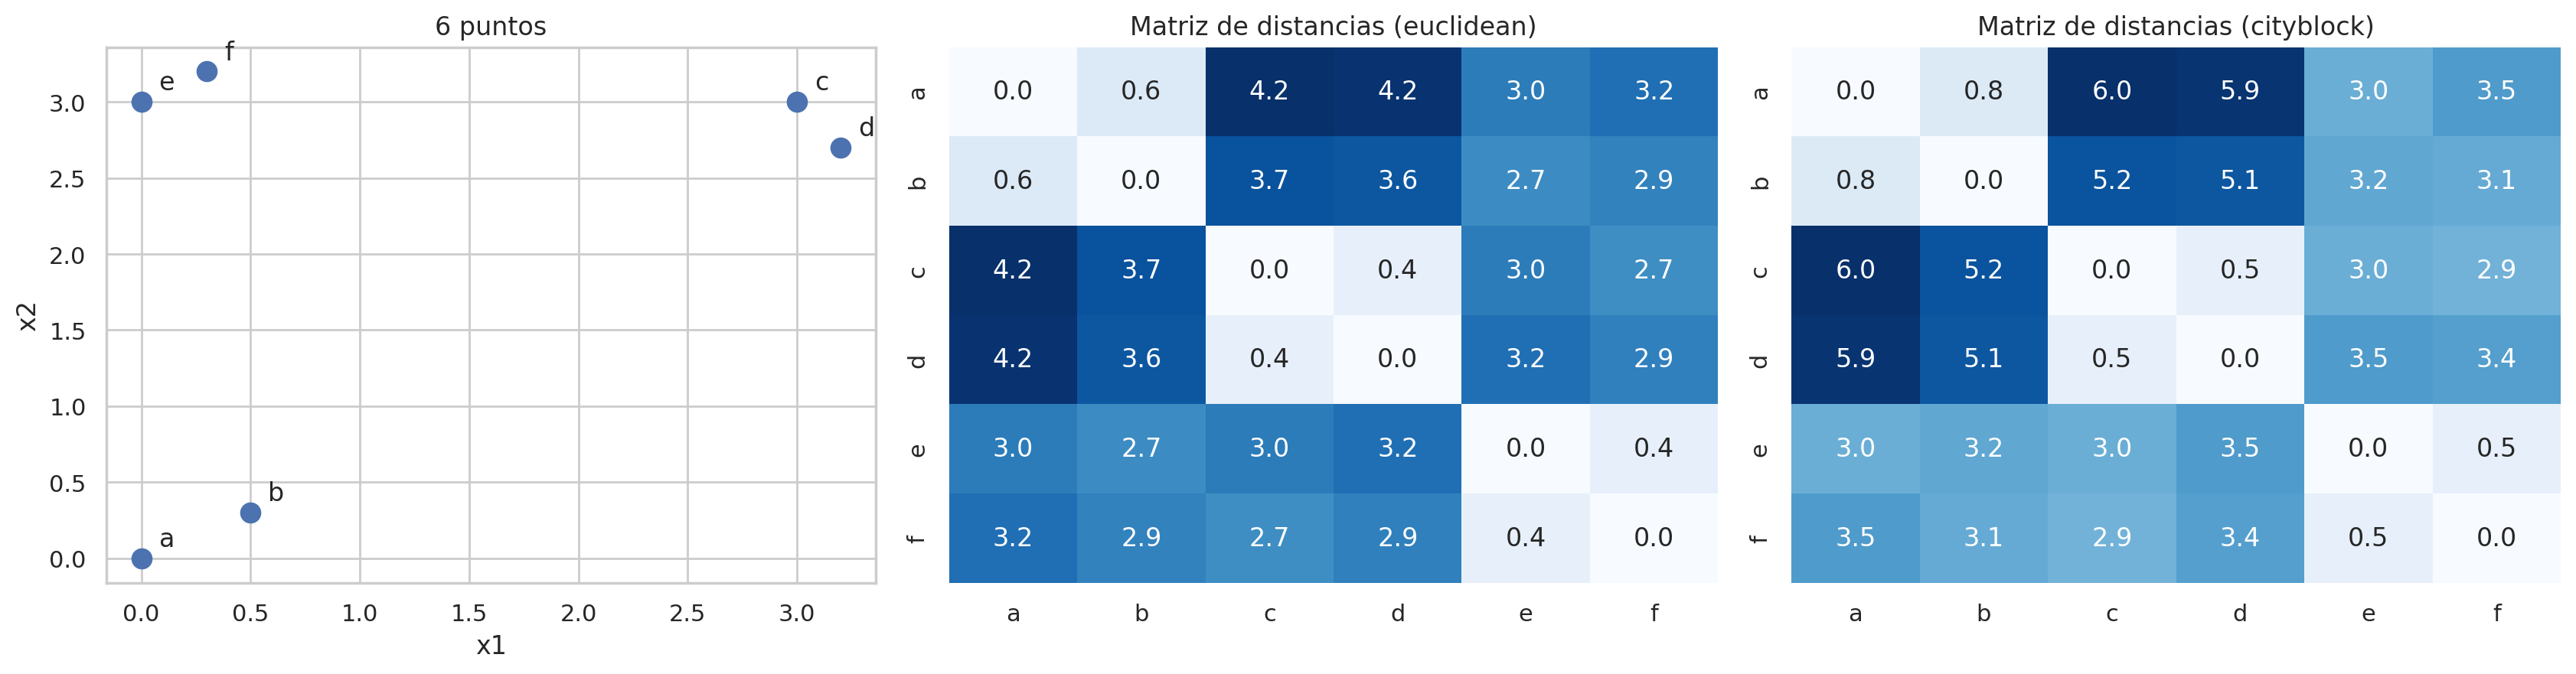

In [28]:
from scipy.spatial.distance import pdist, squareform

# 6 puntos de juguete etiquetados
pts = np.array([[0,0],[0.5,0.3],[3,3],[3.2,2.7],[0,3],[0.3,3.2]], dtype=float)
nom = ['a','b','c','d','e','f']

fig, ax = plt.subplots(1, 3, figsize=(17, 4.6))
ax[0].scatter(pts[:,0], pts[:,1], s=80)
for i,t in enumerate(nom): ax[0].annotate(t,(pts[i,0]+0.08,pts[i,1]+0.08))
ax[0].set_title('6 puntos'); ax[0].set_xlabel('x1'); ax[0].set_ylabel('x2')

for a,met in zip(ax[1:], ['euclidean','cityblock']):    # cityblock = Manhattan
    D = squareform(pdist(pts, metric=met))
    sns.heatmap(D, annot=True, fmt='.1f', xticklabels=nom, yticklabels=nom, cmap="Blues", ax=a, cbar=False)
    a.set_title(f'Matriz de distancias ({met})')
plt.tight_layout(); plt.show()

**Interpretación.** Las dos matrices ordenan las cercanías de forma parecida (los pares $a$–$b$, $c$–$d$, $e$–$f$ son los más próximos), pero **los valores cambian** con la métrica: la Manhattan da distancias mayores en diagonal porque no puede "atajar" en línea recta. Esta matriz de distancias es **el único dato** que necesita el algoritmo jerárquico para empezar a fusionar.

## <font color="steelblue">2.2. Similitudes (variables binarias)</font>

Para variables **binarias** (0/1) se usan **similitudes**. Dada la tabla de coincidencias entre dos muestras:

| $x \backslash y$ | 1 | 0 |
|:---:|:---:|:---:|
| **1** | a | b |
| **0** | c | d |

donde $a$ = nº de variables con 1 en ambas, $d$ = nº con 0 en ambas, y $b,c$ los desacuerdos ($t=a+b+c+d$), las más usadas son:

* **Coeficiente de adecuación simple (SMC)** — proporción de coincidencias (cuenta los ceros comunes):
$$SMC=\frac{a+d}{t}.$$
* **Índice de Jaccard** — proporción de coincidencias en 1 (ignora los ceros comunes), útil cuando el 0 es poco informativo (p. ej. "no compró el producto"):
$$J=\frac{a}{a+b+c}.$$

La diferencia clave es si los **ceros compartidos** cuentan como parecido (SMC) o no (Jaccard).

# <font color="steelblue">3. Métodos de enlace e interpretación geométrica</font>

Con la distancia entre muestras fijada, falta decidir la **distancia entre grupos** $d(A,B)$ —el **método de enlace**— que determina qué par fusionar en cada paso:

* **Vecino más cercano (*single*)** — la **mínima** distancia entre un punto de $A$ y uno de $B$:
$$d(A,B)=\min_{i\in A,\,j\in B} d(i,j).$$
* **Vecino más lejano (*complete*)** — la **máxima**:
$$d(A,B)=\max_{i\in A,\,j\in B} d(i,j).$$
* **Promedio (*average*)** — la media de todas las distancias entre pares:
$$d(A,B)=\frac{1}{n_A n_B}\sum_{i\in A,\,j\in B} d(i,j).$$
* **Centroide (*centroid*)** — la distancia entre los centroides $\bar x_A,\bar x_B$.
* **Ward** — fusiona el par cuya unión produce el **menor incremento de la varianza intra-grupo** (mínima varianza).

| Enlace | Cómo mide | Forma de grupo | Carácter |
|---|---|---|---|
| **single** | salto más corto | **alargada, encadenada** (*chaining*) | sigue formas curvas; sensible a "puentes" de ruido |
| **complete** | salto más largo | **compacta, esférica** | evita encadenamiento; sensible a *outliers* |
| **average** | promedio | intermedia | robusta, equilibrada |
| **centroid** | centro a centro | compacta | puede dar *inversiones* en el dendrograma |
| **ward** | mínima varianza | **compacta y de tamaño parecido** | la opción por defecto; se parece a k-medias |

> **Nota (fórmula de Lance-Williams).** Todos estos enlaces pueden expresarse con una **única fórmula recursiva** que actualiza la distancia de un grupo recién fusionado al resto sin recalcular desde cero; por eso el algoritmo aglomerativo es eficiente y comparten implementación.

## <font color="steelblue">3.1. Ilustración geométrica de los enlaces</font>

Tomamos dos grupos de puntos y dibujamos **qué distancia mide cada enlace** entre ellos.

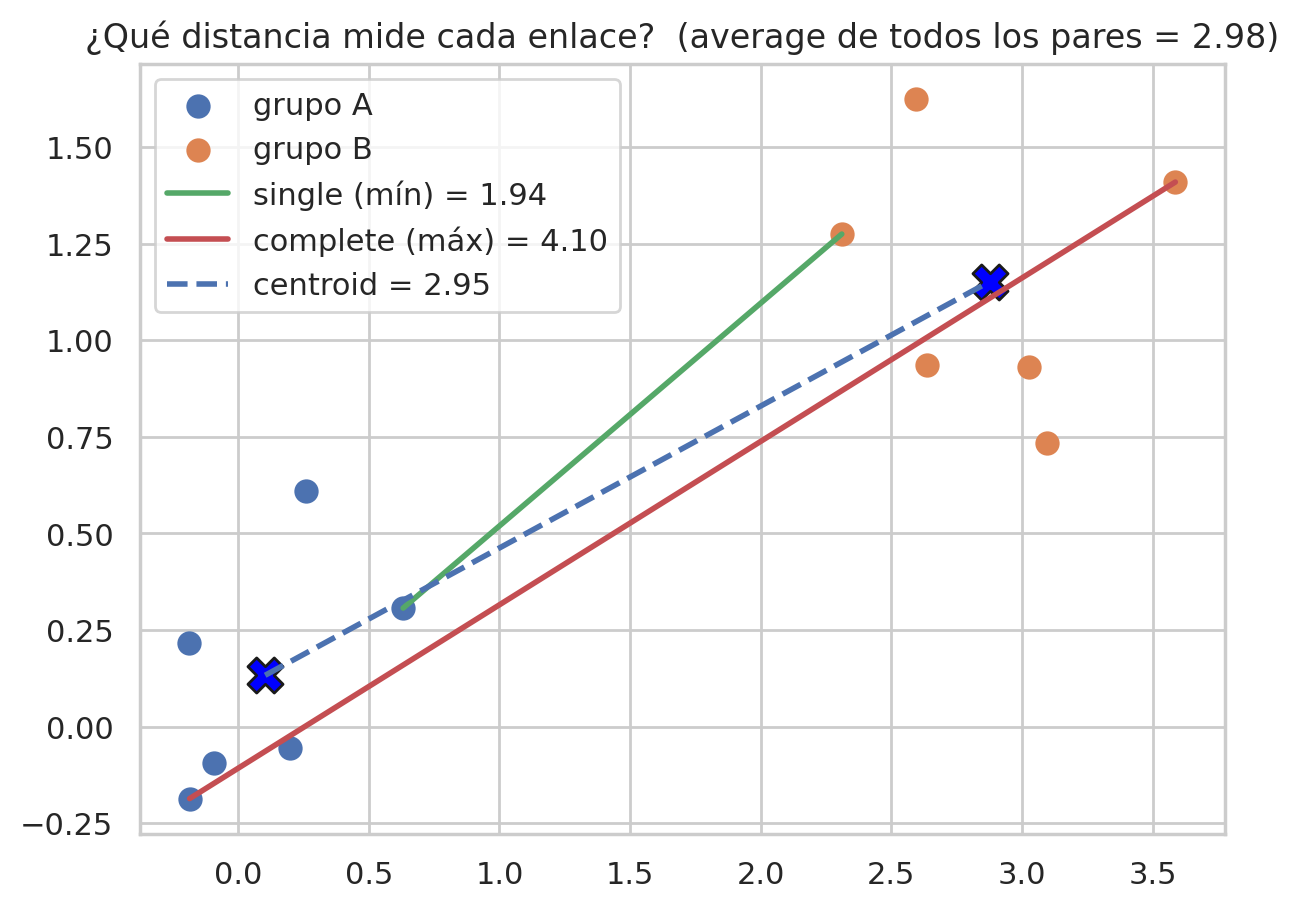

In [30]:
rng = np.random.RandomState(RNG)
A = rng.randn(6, 2) * 0.4 + [0, 0]
B = rng.randn(6, 2) * 0.4 + [3, 1.5]
D = cdist(A, B)
imin = np.unravel_index(D.argmin(), D.shape)      # par más cercano (single)
imax = np.unravel_index(D.argmax(), D.shape)      # par más lejano (complete)
cA, cB = A.mean(0), B.mean(0)                      # centroides

plt.figure(figsize=(7, 5))
plt.scatter(A[:,0], A[:,1], s=60, label='grupo A')
plt.scatter(B[:,0], B[:,1], s=60, label='grupo B')
plt.plot(*zip(A[imin[0]], B[imin[1]]), 'g-',  lw=2, label=f'single (mín) = {D.min():.2f}')
plt.plot(*zip(A[imax[0]], B[imax[1]]), 'r-',  lw=2, label=f'complete (máx) = {D.max():.2f}')
plt.plot(*zip(cA, cB), 'b--', lw=2, label=f'centroid = {np.linalg.norm(cA-cB):.2f}')
plt.scatter(*cA, c='blue', marker='X', s=160, edgecolor='k')
plt.scatter(*cB, c='blue', marker='X', s=160, edgecolor='k')
plt.title(f'¿Qué distancia mide cada enlace?  (average de todos los pares = {D.mean():.2f})')
plt.legend(); plt.show()

**Interpretación.** Sobre los **mismos** dos grupos, cada enlace usa una distancia distinta: **single** toma el segmento **más corto** (verde), **complete** el **más largo** (rojo), **centroid** une los centros (azul) y **average** promedia *todos* los pares. Por eso single tiende a unir grupos que apenas se tocan (encadenamiento) mientras complete exige que **todos** los puntos estén cerca (grupos compactos).

# <font color="steelblue">4. El dendrograma y su construcción</font>

El **dendrograma** es un árbol que registra el orden y la **altura** de cada fusión:

* las **hojas** son las muestras;
* cada **fusión** se dibuja a una **altura igual a la distancia entre los grupos** unidos;
* **cortar** con una línea horizontal produce una partición: el nº de ramas cortadas es el **número de grupos**.

Alturas pequeñas = fusiones entre cosas parecidas; un **salto** grande de altura indica que unimos grupos realmente distintos (buen punto de corte). Lo vemos con 9 puntos.

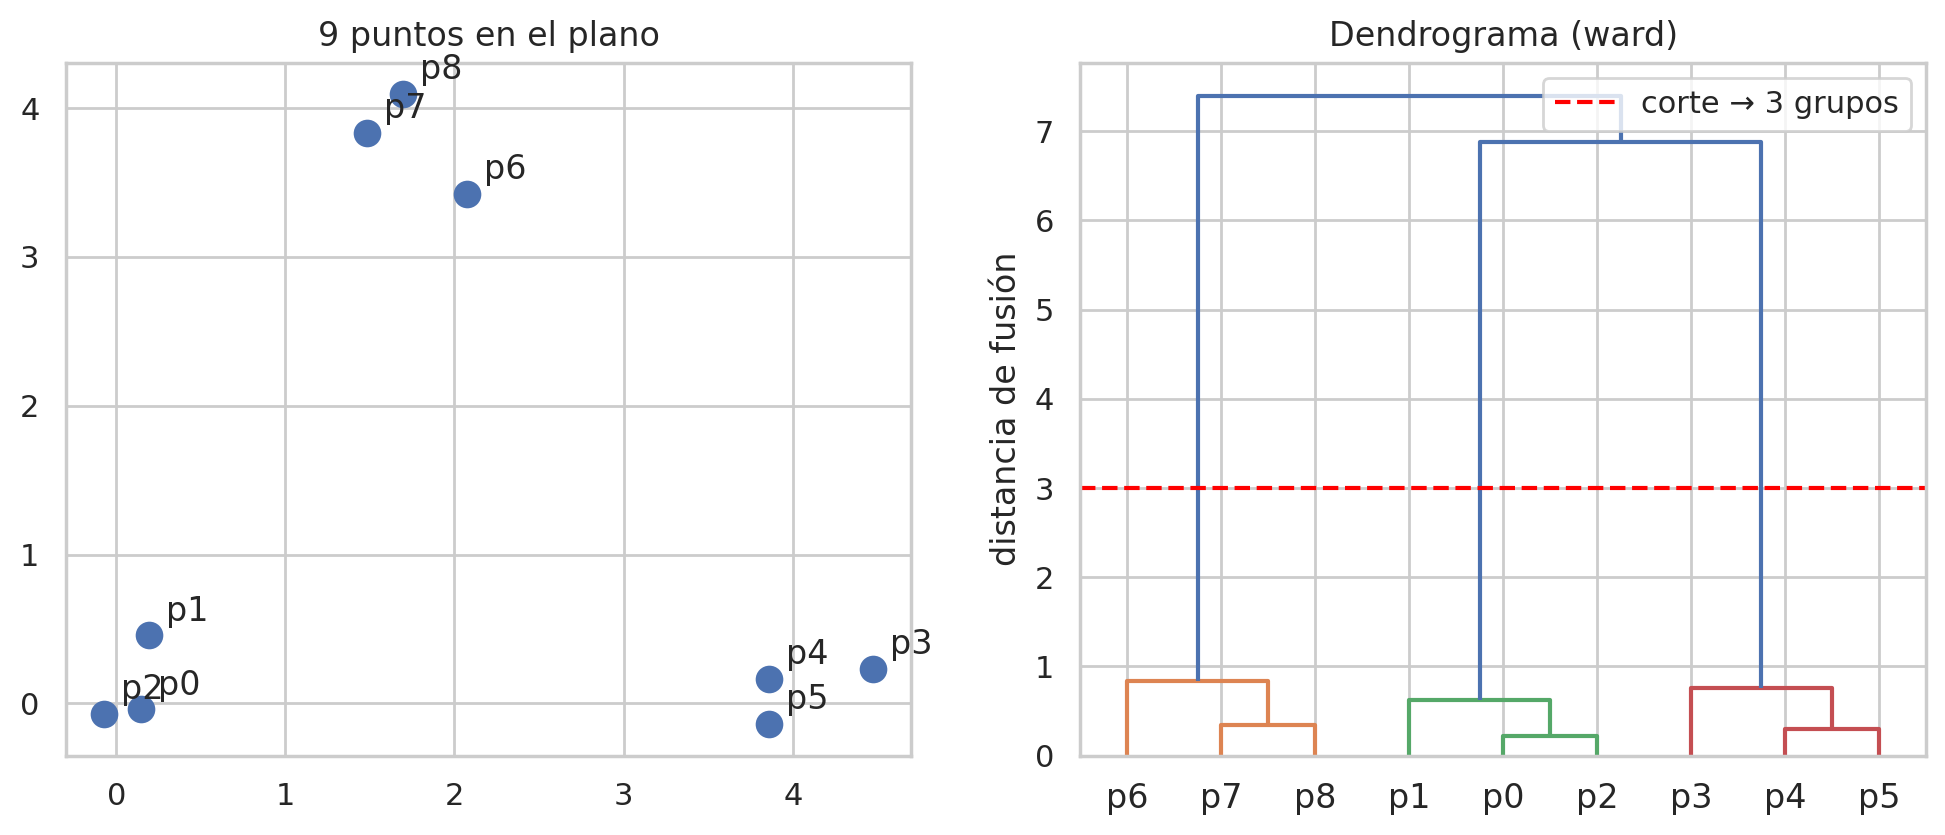

In [33]:
np.random.seed(RNG)
G1 = np.random.randn(3, 2) * 0.3 + [0, 0]
G2 = np.random.randn(3, 2) * 0.3 + [4, 0]
G3 = np.random.randn(3, 2) * 0.3 + [2, 4]
X_toy = np.vstack([G1, G2, G3])
etiquetas = [f'p{i}' for i in range(len(X_toy))]

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
ax[0].scatter(X_toy[:, 0], X_toy[:, 1], s=80)
for i, t in enumerate(etiquetas):
    ax[0].annotate(t, (X_toy[i, 0]+0.1, X_toy[i, 1]+0.1))
ax[0].set_title('9 puntos en el plano')

Z = linkage(X_toy, method='ward')          # matriz de enlace (scipy)
dendrogram(Z, labels=etiquetas, ax=ax[1])
ax[1].axhline(3, color='red', ls='--', label='corte → 3 grupos')
ax[1].set_title('Dendrograma (ward)'); ax[1].set_ylabel('distancia de fusión'); ax[1].legend()
plt.show()

**Interpretación.** Las muestras de cada grupo se fusionan primero **a baja altura**; las tres ramas se unen mucho más arriba tras un **salto** grande: cortar por debajo (línea roja) devuelve los **3 grupos** naturales.

## <font color="steelblue">4.1. Cortar a distintas alturas = elegir el número de grupos</font>

La gran ventaja del dendrograma es que **una sola ejecución** contiene todas las particiones: basta cortar más arriba (menos grupos) o más abajo (más grupos). Lo vemos con `fcluster`, que asigna etiquetas para un número de grupos dado.

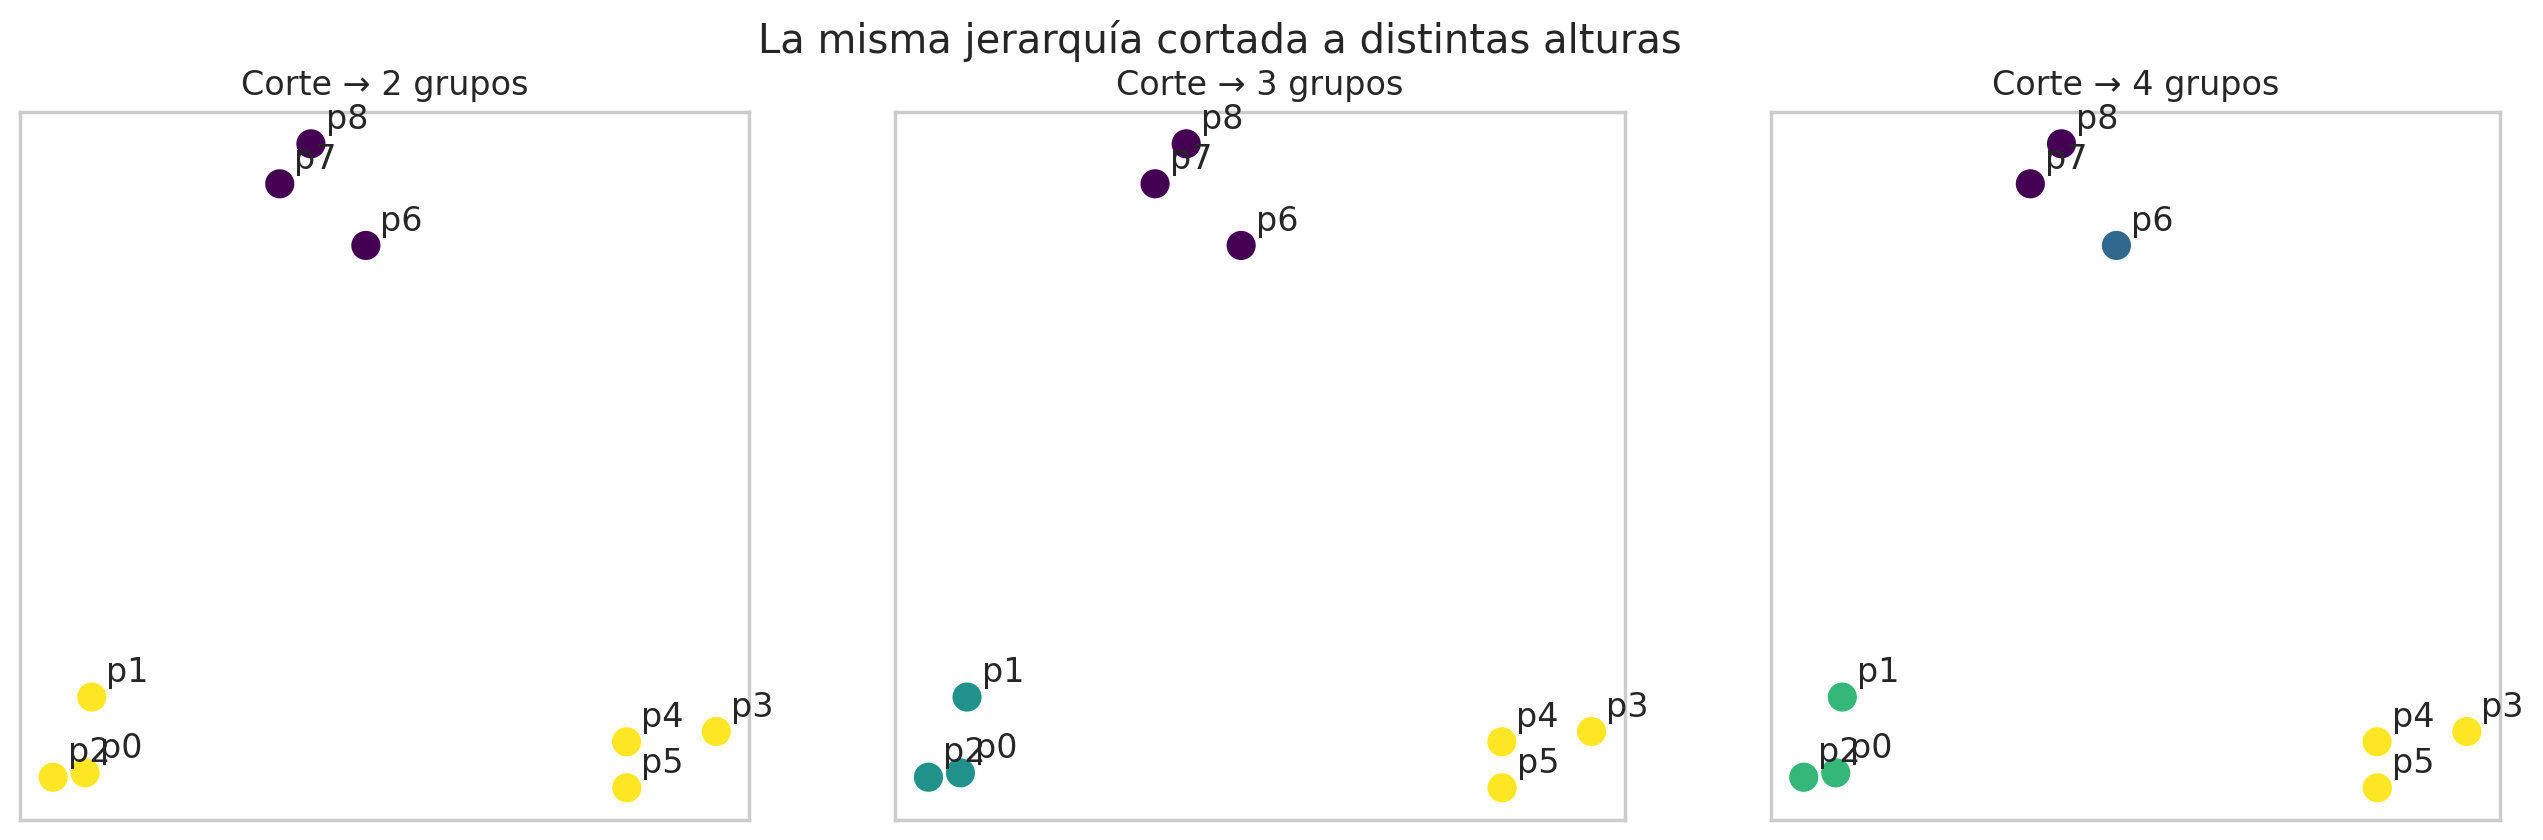

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))
for ax, k in zip(axes, [2, 3, 4]):
    lab = fcluster(Z, t=k, criterion='maxclust')
    ax.scatter(X_toy[:, 0], X_toy[:, 1], c=lab, cmap='viridis', s=90)
    for i, t in enumerate(etiquetas): ax.annotate(t, (X_toy[i,0]+0.1, X_toy[i,1]+0.1))
    ax.set_title(f'Corte → {k} grupos'); ax.set_xticks([]); ax.set_yticks([])
plt.suptitle('La misma jerarquía cortada a distintas alturas'); plt.show()

**Interpretación.** Con $k=2$ se unen los dos grupos más próximos; con $k=3$ aparecen los tres grupos naturales; con $k=4$ uno de ellos se subdivide. No reentrenamos nada: solo **movemos la altura de corte** sobre la misma jerarquía.

# <font color="steelblue">5. Geometría comparada: enlaces y métrica</font>

## <font color="steelblue">5.1. El enlace importa</font>

Aplicamos los cuatro enlaces a tres estructuras (esferas, **lunas**, **círculos**), midiendo el acierto con el **ARI** frente a la estructura real.

> **¿Qué es el ARI (*Adjusted Rand Index*, índice de Rand ajustado)?** Es una métrica que **compara dos agrupaciones** de los mismos datos (aquí, la del algoritmo frente a la estructura real) razonando sobre **pares de puntos**. Parte del **índice de Rand**, que es la proporción de pares en los que ambas particiones **coinciden** —los ponen en el mismo grupo en las dos, o en grupos distintos en las dos—:
> $$RI=\frac{a+b}{\binom{n}{2}},$$
> con $a$ = pares juntos en ambas, $b$ = pares separados en ambas, y $\binom{n}{2}$ el número total de pares. Como incluso dos agrupaciones al azar dan un $RI>0$, el ARI lo **corrige por azar** (se calcula a partir de la tabla de contingencia entre las dos particiones):
> $$ARI=\frac{RI-\mathbb{E}[RI]}{\max(RI)-\mathbb{E}[RI]}.$$
> **Interpretación:** **1** = coincidencia perfecta · **≈0** = como el azar · **<0** = peor que el azar. Su gran ventaja para *clustering* es que es **invariante al nombre de los grupos** (solo importa qué puntos van juntos, no cómo se numeran), por eso se usa en lugar de la *accuracy*. En scikit-learn: `adjusted_rand_score(y_verdadero, etiquetas)`.

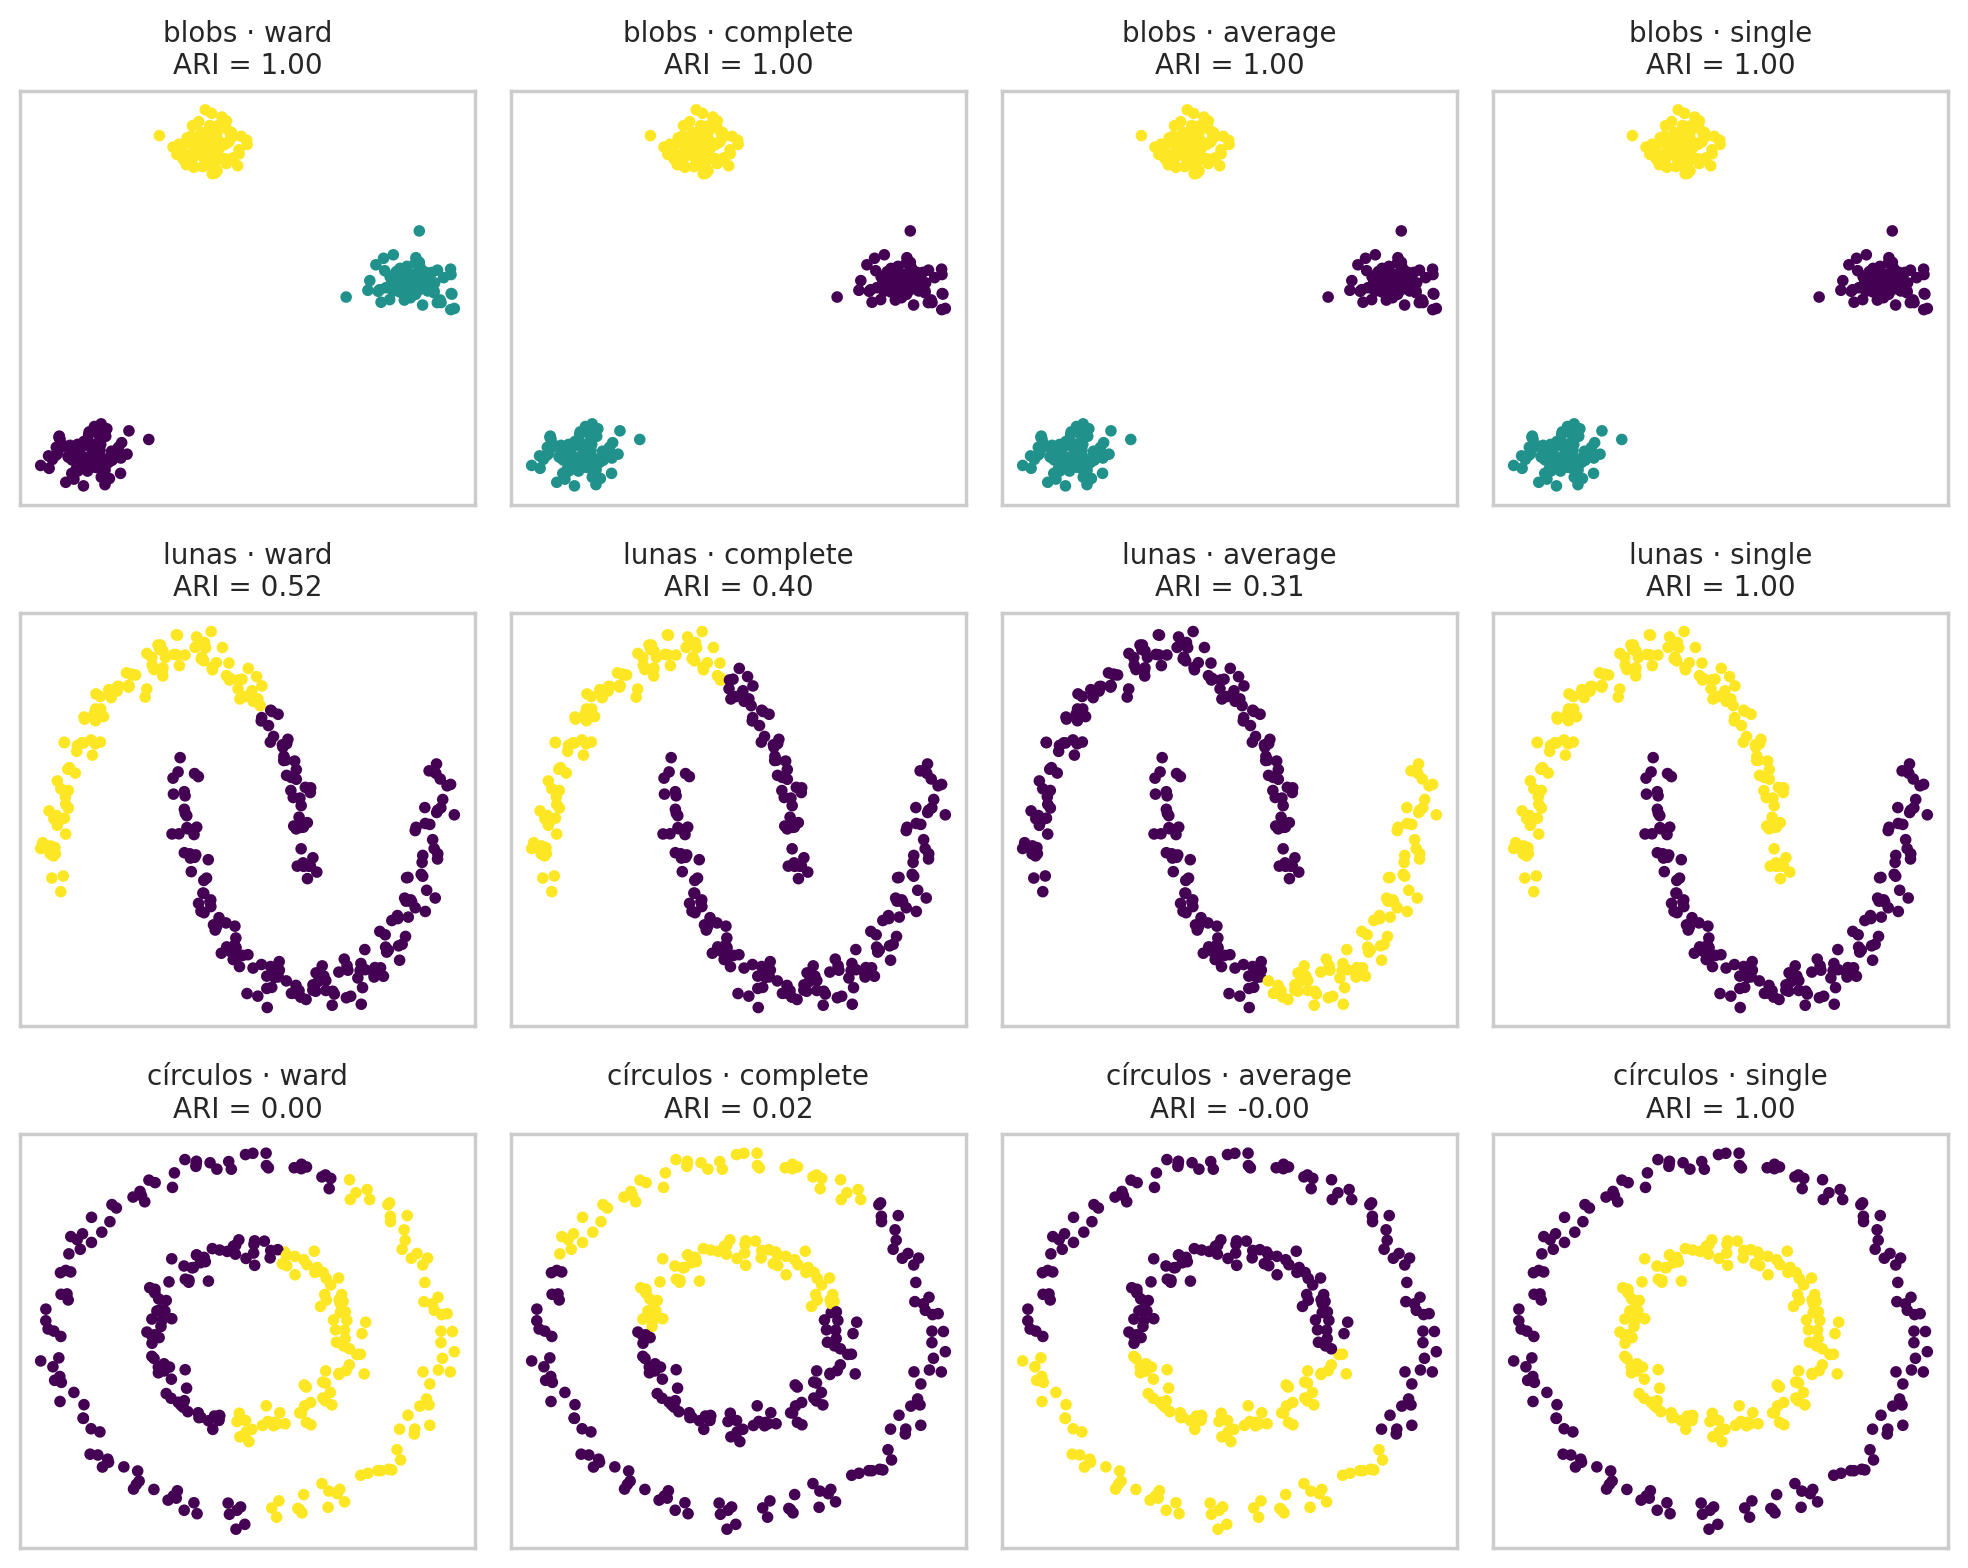

In [38]:
datasets = {
    'blobs':   make_blobs(n_samples=300, centers=3, cluster_std=0.7, random_state=RNG),
    'lunas':   make_moons(n_samples=300, noise=0.05, random_state=RNG),
    'círculos':make_circles(n_samples=300, noise=0.04, factor=0.5, random_state=RNG),
}
enlaces = ['ward', 'complete', 'average', 'single']
fig, axes = plt.subplots(len(datasets), len(enlaces), figsize=(10, 8))
for r, (nombre, (X, y)) in enumerate(datasets.items()):
    k = len(np.unique(y))
    for c, lk in enumerate(enlaces):
        lab = AgglomerativeClustering(n_clusters=k, linkage=lk).fit_predict(X)
        ari = adjusted_rand_score(y, lab)
        ax = axes[r, c]
        ax.scatter(X[:, 0], X[:, 1], c=lab, cmap='viridis', s=10)
        ax.set_title(f'{nombre} · {lk}\nARI = {ari:.2f}', fontsize=10)
        ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

**Interpretación.** En los **blobs** todos aciertan. En **lunas** y **círculos** solo **single** los recupera (ARI = 1.00): encadena puntos vecinos y sigue la curva, mientras que ward/complete/average los parten. Es la ventaja del enlace simple… y su riesgo (un "puente" de ruido fusionaría dos grupos).

## <font color="steelblue">5.2. La métrica entre muestras también importa</font>

No solo el enlace: la **distancia entre muestras** cambia el resultado. Con datos **direccionales** (puntos sobre dos rayos desde el origen), la distancia **euclídea** mezcla los grupos porque mide magnitud, mientras que la **del coseno** (que mide el **ángulo/dirección**) los separa perfectamente.

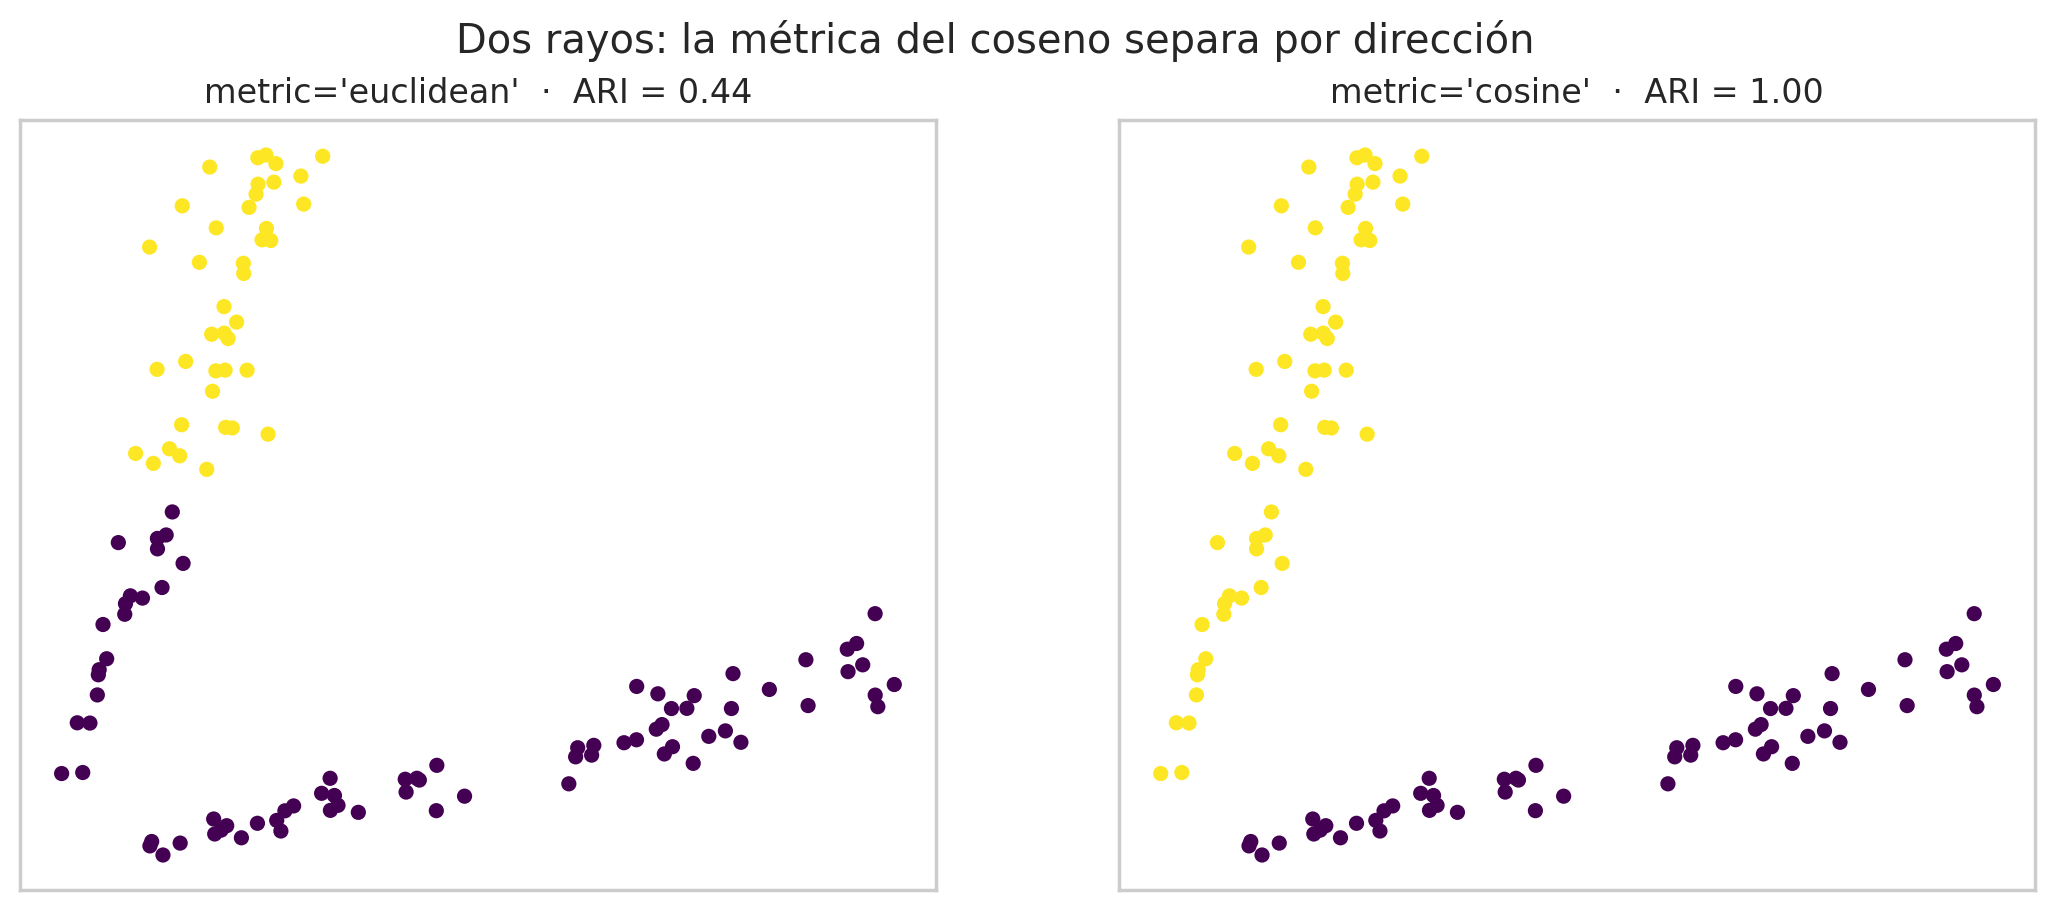

In [39]:
rng = np.random.RandomState(RNG)
ang = np.r_[rng.normal(0.3, 0.05, 60), rng.normal(1.3, 0.05, 60)]
rad = rng.uniform(0.5, 4, 120)
Xd = np.c_[rad*np.cos(ang), rad*np.sin(ang)]
y_dir = np.r_[np.zeros(60), np.ones(60)]

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
for a, met in zip(ax, ['euclidean', 'cosine']):
    lab = AgglomerativeClustering(n_clusters=2, metric=met, linkage='average').fit_predict(Xd)
    a.scatter(Xd[:,0], Xd[:,1], c=lab, cmap='viridis', s=20)
    a.set_title(f"metric='{met}'  ·  ARI = {adjusted_rand_score(y_dir, lab):.2f}")
    a.set_xticks([]); a.set_yticks([])
plt.suptitle('Dos rayos: la métrica del coseno separa por dirección'); plt.show()

**Interpretación.** Con la **euclídea** (ARI bajo) los puntos lejanos del mismo rayo parecen más distintos que puntos cercanos de rayos distintos, y la agrupación falla. Con el **coseno** (ARI = 1.00), lo que importa es la **dirección**, así que cada rayo forma su grupo. Moraleja: elegir bien **la métrica entre muestras** es tan importante como el enlace (recuerda que `ward` solo admite euclídea).

# <font color="steelblue">6. Clustering jerárquico en scikit-learn</font>

La clase es **`sklearn.cluster.AgglomerativeClustering`**. Parámetros principales:

* **`metric`**: distancia entre muestras (`'euclidean'`, `'l1'`, `'l2'`, `'manhattan'`, `'cosine'`, `'precomputed'`). Con `linkage='ward'` solo se admite `'euclidean'`. *(En versiones < 1.2 se llamaba `affinity`.)*
* **`linkage`**: `'ward'` (def.), `'complete'`, `'average'`, `'single'`.
* **`n_clusters`**: número de grupos a devolver, **o** bien…
* **`distance_threshold`**: altura de corte (con `n_clusters=None`); el modelo corta el árbol a esa altura (sección 6.3). Útil además para obtener el **árbol completo** con `distance_threshold=0`.
* **`compute_full_tree`**: `'auto'` por defecto; con `distance_threshold` se fuerza el árbol completo.
* **`compute_distances`**: guarda las distancias de fusión (necesario para dibujar el dendrograma desde el modelo de sklearn).
* **`connectivity`**: restringe las fusiones a vecinos (sección 6.4).

Tras ajustar, el modelo expone como **atributos**: `labels_` (grupo de cada muestra), `n_clusters_`, `n_leaves_`, `children_` (las fusiones), `distances_` (sus alturas) y `n_connected_components_`.

## <font color="steelblue">6.1. Del modelo de scikit-learn al dendrograma</font>

`AgglomerativeClustering` **no dibuja** el dendrograma; quien lo dibuja es `scipy`. El puente es el atributo **`children_`**: una matriz $(n-1)\times 2$ donde la fila $i$ son los dos nodos fusionados en el paso $i$. Un índice **menor que $n$** es una **muestra original**; uno **mayor o igual que $n$** es un **cluster ya formado** (el del paso `índice − n`). Con `children_`, las alturas **`distances_`** (de ahí `compute_distances=True`) y el recuento de muestras por rama, reconstruimos la **matriz de enlace** que espera `scipy` (`[hijo1, hijo2, distancia, nº de muestras]`). Eso es justo lo que hace esta función auxiliar.

In [40]:
def plot_dendrogram(model, **kwargs):
    """Dibuja el dendrograma a partir de un AgglomerativeClustering ya ajustado
    con compute_distances=True (o distance_threshold). Acepta los mismos kwargs
    que scipy.cluster.hierarchy.dendrogram (truncate_mode, p, color_threshold, ax...)."""
    counts = np.zeros(model.children_.shape[0])     # nº de muestras bajo cada fusión
    n = len(model.labels_)
    for i, merge in enumerate(model.children_):
        c = 0
        for child in merge:
            c += 1 if child < n else counts[child - n]   # hoja (1) o sub-cluster (su recuento)
        counts[i] = c
    Z = np.column_stack([model.children_, model.distances_, counts]).astype(float)
    return dendrogram(Z, **kwargs)

Sobre un conjunto **pequeño** el árbol completo es legible. Ajustamos con `distance_threshold=0` y `n_clusters=None` para obtener **todas** las fusiones.

children_: (8, 2) | distances_: (8,) | n_leaves_: 9


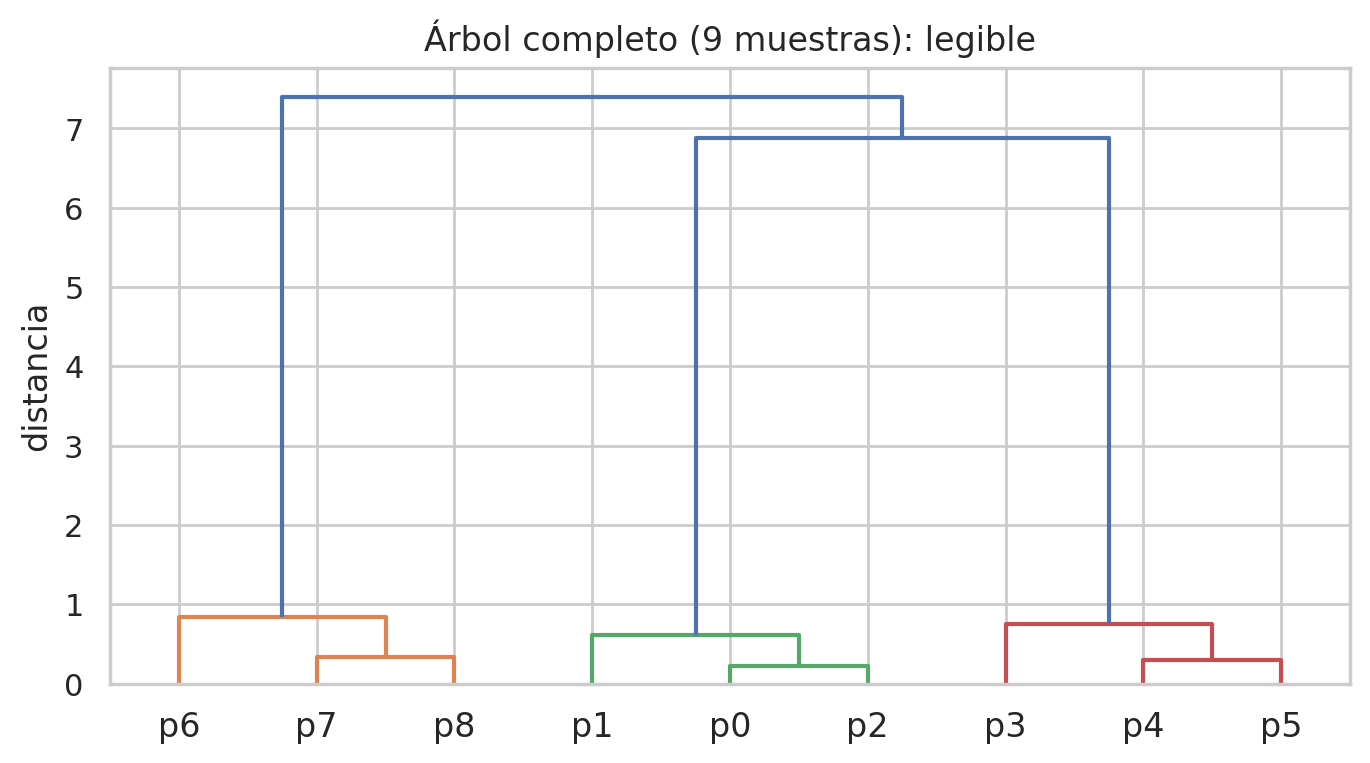

In [42]:
modelo_full = AgglomerativeClustering(distance_threshold=0, n_clusters=None,
                                      compute_distances=True).fit(X_toy)
print('children_:', modelo_full.children_.shape, '| distances_:', modelo_full.distances_.shape,
      '| n_leaves_:', modelo_full.n_leaves_)

plt.figure(figsize=(8, 4))
plot_dendrogram(modelo_full, labels=etiquetas)
plt.title('Árbol completo (9 muestras): legible'); plt.ylabel('distancia'); plt.show()

## <font color="steelblue">6.2. Truncamiento del dendrograma con muchas muestras</font>

Con cientos o miles de hojas, el dendrograma completo se convierte en un "peine" negro **ilegible**: no caben las etiquetas ni se distinguen las ramas. La solución es **truncar** el árbol mostrando solo su parte superior (las últimas fusiones, que son las que de verdad nos importan para elegir grupos). Tanto la función anterior como `scipy.cluster.hierarchy.dendrogram` aceptan estos argumentos:

* **`truncate_mode='lastp'` + `p`**: colapsa el árbol y muestra **solo los $p$ nodos superiores** (las $p$ últimas fusiones). Cada hoja del dibujo ya no es una muestra, sino **una rama entera**; con **`show_leaf_counts=True`** su etiqueta es **`(N)`**, el **número de muestras** que contiene esa rama colapsada.
* **`truncate_mode='level'` + `p`**: muestra solo los **$p$ niveles superiores** del árbol.
* **`color_threshold=t`**: colorea de un color distinto cada rama que nace por debajo de la altura $t$ (ayuda a "ver" los grupos).
* **`show_contracted=True`**: dibuja como pequeñas marcas las fusiones contraídas, para no perder la noción de las alturas inferiores.

Lo vemos sobre **500 muestras**: el árbol completo (izquierda) es inservible; truncado es claro.

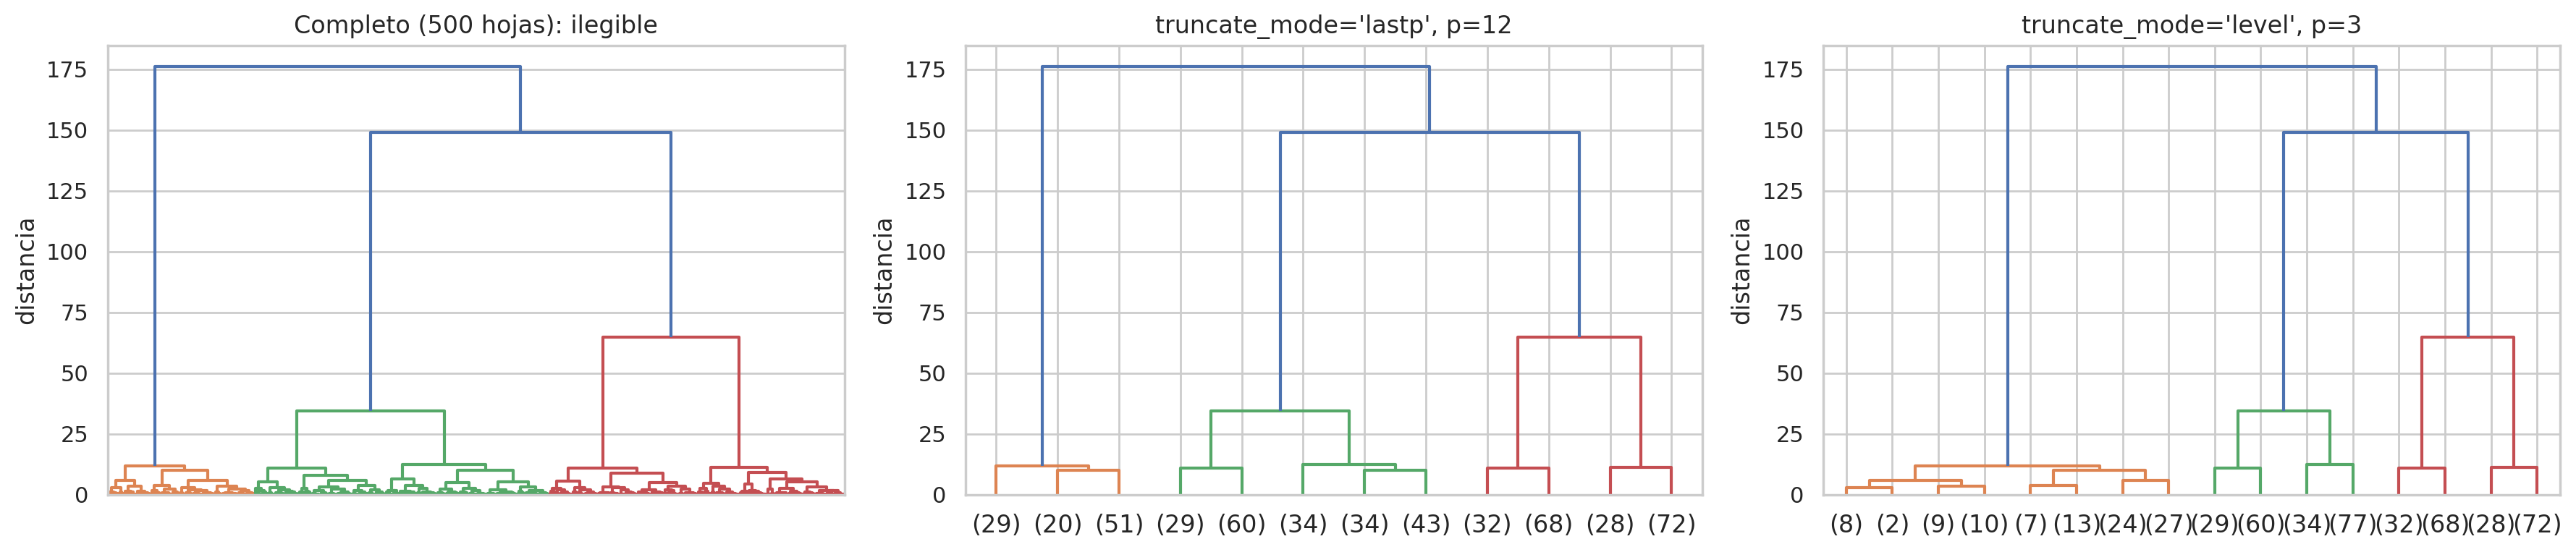

In [48]:
X_big, _ = make_blobs(n_samples=500, centers=5, cluster_std=1.0, random_state=RNG)
modelo_big = AgglomerativeClustering(distance_threshold=0, n_clusters=None,
                                     linkage='ward', compute_distances=True).fit(X_big)
# Gráficos dendograma
fig, ax = plt.subplots(1, 3, figsize=(18, 4))
plot_dendrogram(modelo_big, no_labels=True, ax=ax[0])
ax[0].set_title('Completo (500 hojas): ilegible')

plot_dendrogram(modelo_big, truncate_mode='lastp', p=12, show_leaf_counts=True, ax=ax[1])
ax[1].set_title("truncate_mode='lastp', p=12")

plot_dendrogram(modelo_big, truncate_mode='level', p=3, ax=ax[2])
ax[2].set_title("truncate_mode='level', p=3")
for a in ax: a.set_ylabel('distancia')
plt.tight_layout(); plt.show()

**Interpretación.** A la izquierda no se distingue nada. Con **`lastp` (p=12)** vemos solo las 12 ramas superiores: cada etiqueta `(N)` indica cuántas de las 500 muestras hay en esa rama (p. ej. `(71)`), y el **gran salto** de altura donde se separan ~5 grupos es ahora evidente. Con **`level` (p=3)** vemos los 3 niveles superiores del árbol. En ambos casos conservamos lo importante —las **alturas de fusión** y el **tamaño** de cada rama— y perdemos solo el detalle de las hojas individuales, que con miles de muestras no aporta. **Este es exactamente el truncamiento que usamos en la aplicación de Google reviews** (sección 8.2), con `truncate_mode='lastp'`.

> **Truco práctico.** El árbol completo de miles de muestras es **caro** de calcular y dibujar. Si solo quieres decidir el número de grupos, suele bastar con `scipy.cluster.hierarchy.linkage(X, method=...)` + `dendrogram(Z, truncate_mode='lastp', p=...)`, sin construir el árbol entero con sklearn.

## <font color="steelblue">6.3. Elegir el número de grupos por altura: `distance_threshold`</font>

En vez de fijar `n_clusters`, podemos fijar la **altura de corte** con `distance_threshold` (y `n_clusters=None`): el modelo corta el árbol a esa altura y nos dice cuántos grupos resultan en `n_clusters_`. Es el equivalente "automático" a trazar la línea horizontal sobre el dendrograma.

In [49]:
for t in [10, 20, 40]:
    m = AgglomerativeClustering(distance_threshold=t, n_clusters=None, linkage='ward').fit(X_big)
    print(f'distance_threshold = {t:>2}  ->  {m.n_clusters_} grupos')

distance_threshold = 10  ->  11 grupos
distance_threshold = 20  ->  5 grupos
distance_threshold = 40  ->  4 grupos


**Interpretación.** Al **subir** la altura de corte se obtienen **menos** grupos (cortamos más arriba en el árbol). Combinando esto con el dendrograma truncado, se elige el umbral que cae **dentro del gran salto** de altura, que es donde la partición es más estable.

## <font color="steelblue">6.4. Restricciones de conectividad</font>

Por defecto, el algoritmo aglomerativo puede fusionar **cualquier** par de grupos: solo mira distancias, **ignorando** si están realmente "pegados" en el espacio. El parámetro **`connectivity`** cambia esto pasándole un **grafo** que indica **qué muestras son vecinas admisibles**; a partir de ahí, **solo se permiten fusiones entre grupos conectados en el grafo**. En la práctica le damos al algoritmo conocimiento de la **topología** de los datos.

**Qué representa, en concreto:**
* Sin conectividad (`connectivity=None`) ≡ grafo **completo** (todo conecta con todo) → agrupamiento puramente por distancia.
* Con conectividad, típicamente un grafo de **$k$ vecinos más próximos** (`kneighbors_graph`) o de **radio** (`radius_neighbors_graph`); para imágenes, un grafo de **rejilla** (píxeles contiguos); para datos geográficos, la **adyacencia** entre regiones.

**Para qué sirve:** (1) **respetar la estructura/manifold** —impide fusiones que "saltan" por el vacío y une solo lo contiguo—, y (2) **eficiencia** —un grafo disperso reduce muchísimo las fusiones candidatas, ahorrando tiempo y memoria en datos grandes—. Empezamos con un ejemplo sencillo sobre las medias lunas.

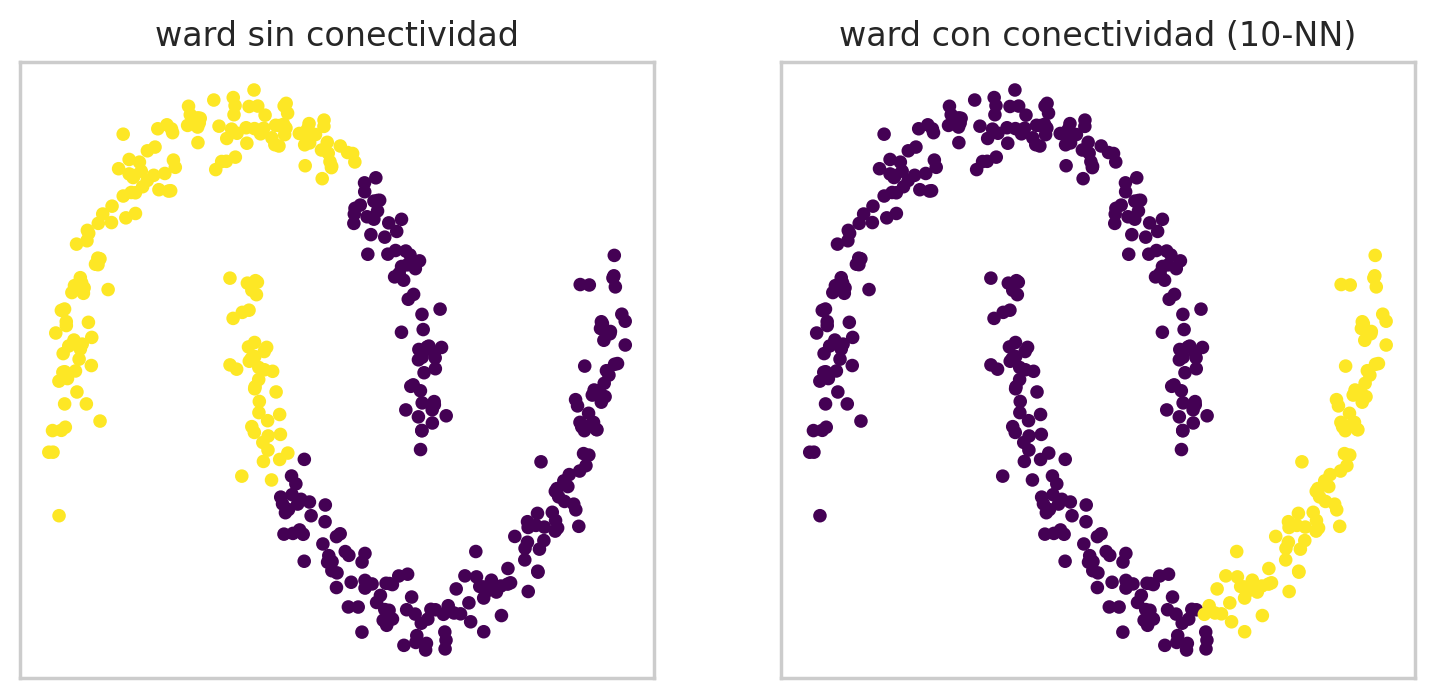

In [52]:
X, y = make_moons(n_samples=400, noise=0.06, random_state=RNG)
conn = kneighbors_graph(X, n_neighbors=10, include_self=False)

fig, ax = plt.subplots(1, 2, figsize=(9, 4))
for a, (c, titulo) in zip(ax, [(None, 'ward sin conectividad'),
                               (conn, 'ward con conectividad (10-NN)')]):
    lab = AgglomerativeClustering(n_clusters=2, linkage='ward', connectivity=c).fit_predict(X)
    a.scatter(X[:, 0], X[:, 1], c=lab, cmap='viridis', s=15)
    a.set_title(titulo); a.set_xticks([]); a.set_yticks([])
plt.show()

**Interpretación.** La conectividad hace que las fusiones de `ward` ocurran solo entre **puntos vecinos**, produciendo grupos **espacialmente contiguos** (sin "saltos" por el hueco entre lunas).

**El ejemplo canónico: el *swiss roll*.** El efecto se ve mucho mejor en una variedad enrollada en 3D. Sin conectividad, `ward` fusiona puntos **cercanos en línea recta** aunque estén en **vueltas distintas** del rollo; con un grafo de vecinos, las fusiones siguen la **superficie** del rollo.

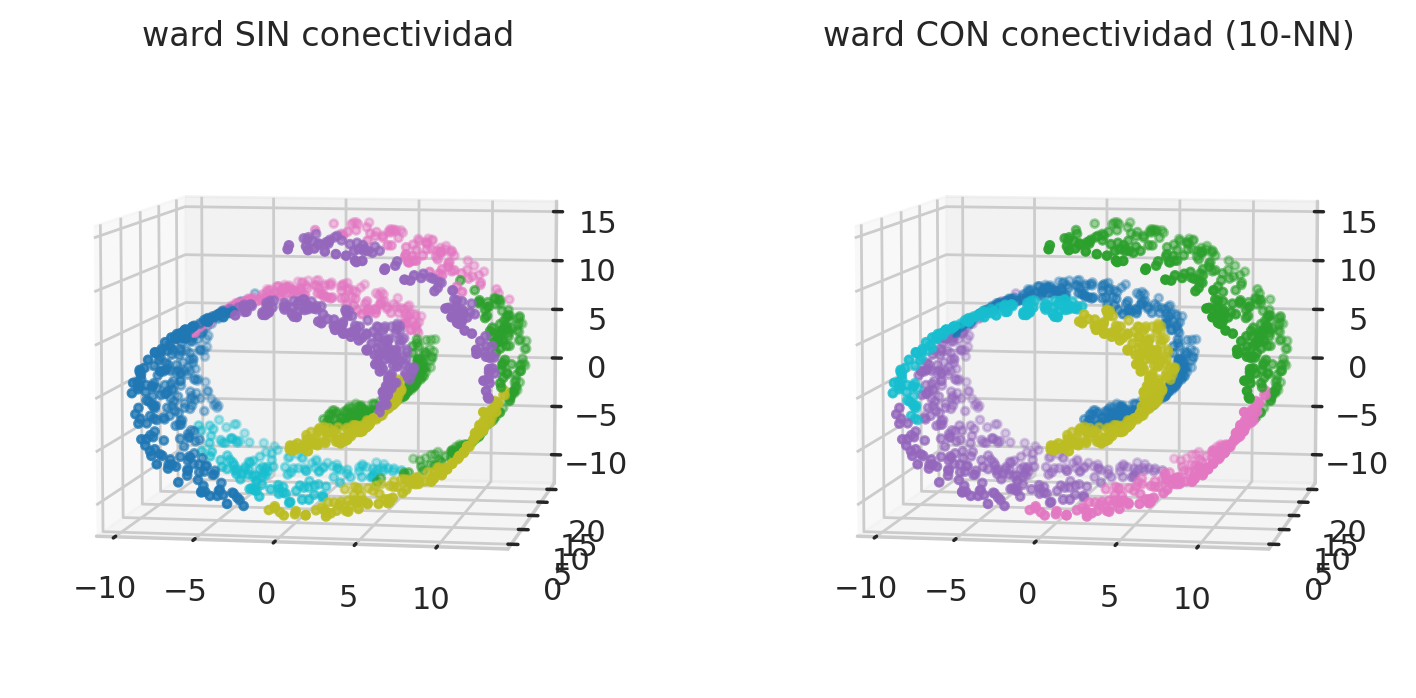

In [53]:
from sklearn.datasets import make_swiss_roll
Xsr, _ = make_swiss_roll(n_samples=1500, noise=0.05, random_state=RNG)
conn_sr = kneighbors_graph(Xsr, n_neighbors=10, include_self=False)

lab_sin = AgglomerativeClustering(n_clusters=6, linkage='ward').fit_predict(Xsr)
lab_con = AgglomerativeClustering(n_clusters=6, linkage='ward', connectivity=conn_sr).fit_predict(Xsr)

fig = plt.figure(figsize=(9, 4))
for i, (lab, titulo) in enumerate([(lab_sin, 'ward SIN conectividad'),
                                   (lab_con, 'ward CON conectividad (10-NN)')], start=1):
    ax = fig.add_subplot(1, 2, i, projection='3d')
    ax.scatter(Xsr[:, 0], Xsr[:, 1], Xsr[:, 2], c=lab, cmap='tab10', s=8)
    ax.set_title(titulo); ax.view_init(7, -80)
plt.show()

**Interpretación.** Sin conectividad (izquierda) los grupos **cortan el rollo en bloques**, uniendo vueltas que solo están próximas "en el aire"; con conectividad (derecha) cada grupo es una **banda continua a lo largo del rollo**: el algoritmo ha respetado la geometría de la variedad. No convierte a `ward` en detector de formas arbitrarias —para eso el enlace **single** sigue siendo lo natural— pero lo hace consciente de la estructura local.

**Aviso práctico — número de vecinos.** Si el grafo tiene **muy pocos** vecinos puede quedar **desconectado** en varias piezas, y el modelo **no puede** dar menos grupos que componentes conexas (lo refleja el atributo `n_connected_components_`). Demasiados vecinos lo acercan a "sin conectividad".

In [54]:
for nn in [2, 5, 10, 30]:
    c = kneighbors_graph(Xsr, n_neighbors=nn, include_self=False)
    m = AgglomerativeClustering(n_clusters=6, linkage='ward', connectivity=c).fit(Xsr)
    print(f'n_neighbors = {nn:>2}  ->  n_connected_components_ = {m.n_connected_components_}')

n_neighbors =  2  ->  n_connected_components_ = 81
n_neighbors =  5  ->  n_connected_components_ = 1
n_neighbors = 10  ->  n_connected_components_ = 1
n_neighbors = 30  ->  n_connected_components_ = 1


**Interpretación.** Con `n_neighbors=2` el grafo se **fragmenta** en decenas de componentes (cada trocito aislado fuerza su propio grupo); a partir de unos pocos vecinos el grafo es **conexo** y la conectividad cumple su función sin fragmentar. En la práctica, 10–30 vecinos suele ser un buen punto de partida.

## <font color="steelblue">6.5. FeatureAgglomeration</font>

La misma maquinaria jerárquica puede aplicarse a las **columnas** en vez de a las filas. **`FeatureAgglomeration`** trata cada **variable** como un punto descrito por sus valores **a lo largo de todas las muestras**, construye la jerarquía sobre esas variables y, al cortar en `n_clusters` grupos, **fusiona** las variables de cada grupo en una sola (por defecto, promediándolas; configurable con `pooling_func`). Es, por tanto, una **reducción de dimensión** que agrupa características **redundantes o correlacionadas**.

Frente a **PCA**: la PCA crea combinaciones lineales de **todas** las variables (componentes densas y difíciles de interpretar); `FeatureAgglomeration` crea **grupos disjuntos de variables originales**, así que el resultado es **interpretable** ("estas variables se comportan igual"). Además, `inverse_transform` devuelve cada meta-variable a su grupo (rellenando todas con el valor agregado), lo que permite **visualizar** el efecto. Lo vemos en los dígitos (64 píxeles), agrupándolos en 16.

De 64 píxeles a 16 grupos de píxeles


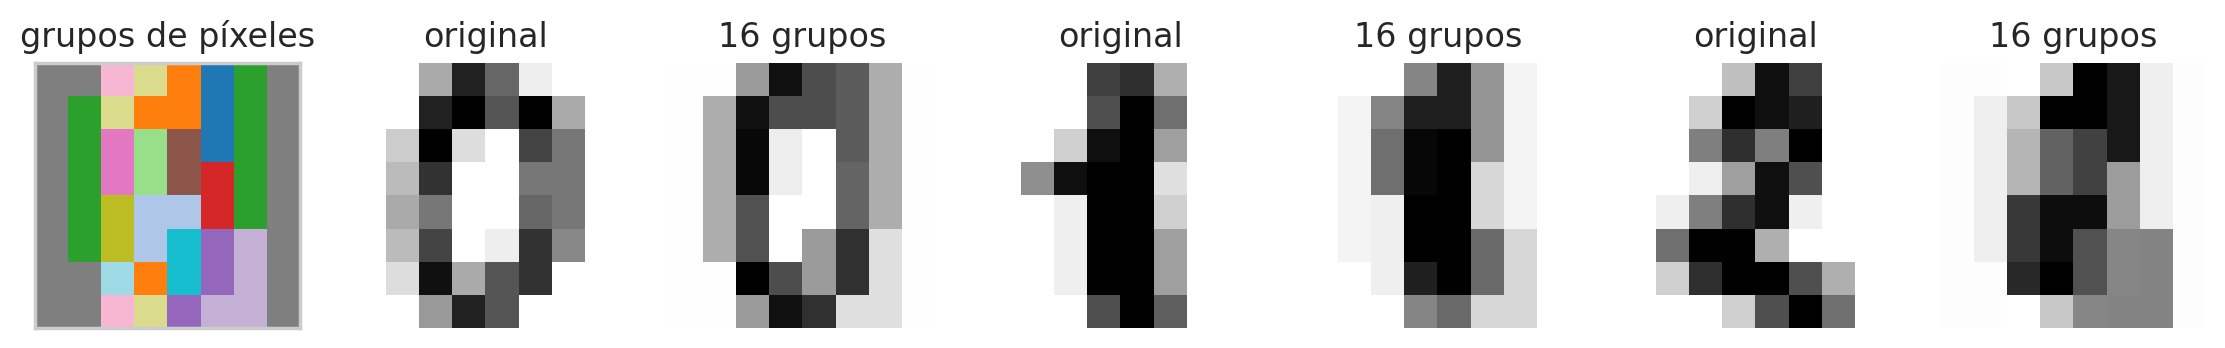

In [55]:
from sklearn.datasets import load_digits
digits = load_digits()
fa = FeatureAgglomeration(n_clusters=16).fit(digits.data)
print('De', digits.data.shape[1], 'píxeles a', fa.transform(digits.data).shape[1], 'grupos de píxeles')

X_rec = fa.inverse_transform(fa.transform(digits.data))   # reconstrucción "engrosada"

fig, ax = plt.subplots(1, 7, figsize=(14, 2.4))
ax[0].imshow(fa.labels_.reshape(8, 8), cmap='tab20')      # qué píxeles caen en cada grupo
ax[0].set_title('grupos de píxeles'); ax[0].set_xticks([]); ax[0].set_yticks([])
for j in range(3):
    ax[1+2*j].imshow(digits.data[j].reshape(8, 8), cmap='binary'); ax[1+2*j].set_title('original'); ax[1+2*j].axis('off')
    ax[2+2*j].imshow(X_rec[j].reshape(8, 8), cmap='binary'); ax[2+2*j].set_title('16 grupos'); ax[2+2*j].axis('off')
plt.show()

**Interpretación.** El primer panel muestra cómo los 64 píxeles se reparten en **16 grupos** (píxeles **vecinos y correlacionados** caen juntos, formando regiones contiguas de la imagen). Las parejas original/reconstruido muestran que, al colapsar cada grupo a su valor medio, la imagen queda **engrosada** pero **sigue siendo reconocible**: hemos pasado de 64 a 16 variables conservando lo esencial, y —a diferencia de PCA— sabiendo exactamente **qué píxeles** componen cada nueva variable.

# <font color="steelblue">7. Elección del número de grupos</font>

Cuando **no hay etiquetas** (lo habitual en *clustering*), elegimos $k$ con **criterios internos** que miden cohesión y separación:

**Coeficiente de silueta** (Rousseeuw). Para cada muestra $i$ compara su **cohesión** $a(i)$ (distancia media a las demás muestras de **su** grupo) con su **separación** $b(i)$ (distancia media a las del grupo **vecino más cercano**):

$$s(i)=\frac{b(i)-a(i)}{\max(a(i),\,b(i))}\in[-1,1].$$

Cercano a **1** = muestra bien agrupada; **≈0** = en la frontera entre dos grupos; **negativo** = probablemente mal asignada. Se promedia sobre todas las muestras (`silhouette_score`) y se elige el $k$ que lo **maximiza**.

**Calinski-Harabasz** (`calinski_harabasz_score`): razón entre la dispersión **entre** grupos y la dispersión **dentro** de los grupos; **mayor = mejor**. **Davies-Bouldin** (`davies_bouldin_score`): similitud media de cada grupo con su grupo más parecido; **menor = mejor**.

En la práctica combinamos tres herramientas:

1. **Cortar el dendrograma** donde hay un **salto** grande de altura de fusión.
2. **Gráfico scree** del índice de silueta frente al número de grupos (función auxiliar).
3. Contrastar con **Calinski-Harabasz** (mayor mejor) y **Davies-Bouldin** (menor mejor).

In [56]:
def plot_scree(X, metric, linkage_m, kmin, kmax, **kwargs):
    """Índice de silueta para soluciones jerárquicas de kmin a kmax grupos."""
    ks = range(kmin, kmax)
    sil = [silhouette_score(X, AgglomerativeClustering(n_clusters=k, metric=metric,
                                                       linkage=linkage_m).fit_predict(X)) for k in ks]
    plt.plot(list(ks), sil, marker='o', **kwargs)
    plt.xlabel('número de grupos'); plt.ylabel('silueta media'); plt.xticks(list(ks))

# <font color="steelblue">8. Aplicaciones</font>

Aplicamos lo aprendido a **dos casos complementarios**: en **Vinos (8.1)** disponemos de la etiqueta real, lo que permite **comparar enlaces, elegir $k$ y validar** la agrupación contra las clases conocidas; en **Google reviews (8.2)** no hay etiqueta, así que es un caso de **segmentación pura**, donde veremos qué hacer cuando los datos **no forman grupos nítidos**.



## <font color="steelblue">8.1. Vinos (con validación)</font>

Tres tipos de vino (13 variables). Comparamos los enlaces, elegimos uno y validamos contra la etiqueta real.

In [57]:
vinos = pd.read_csv('https://archive.ics.uci.edu/ml/machine-learning-databases/wine/wine.data', header=None)
vinos.columns = ['Class label', 'Alcohol', 'Malic acid', 'Ash',
'Alcalinity of ash', 'Magnesium', 'Total phenols',
'Flavanoids', 'Nonflavanoid phenols', 'Proanthocyanins',
'Color intensity', 'Hue', 'OD280/OD315 of diluted wines', 'Proline']
y_vinos = vinos['Class label'].values
X_vinos = StandardScaler().fit_transform(vinos.drop(columns='Class label'))

print('Silueta por enlace (k=3):')
for lk in ['ward', 'complete', 'average', 'single']:
    lab = AgglomerativeClustering(n_clusters=3, linkage=lk).fit_predict(X_vinos)
    print(f'  {lk:9s}: {silhouette_score(X_vinos, lab):.3f}')

Silueta por enlace (k=3):
  ward     : 0.277
  complete : 0.204
  average  : 0.158
  single   : 0.183


El enlace **ward** da la mejor silueta. Ahora **elegimos el número de grupos** con los criterios de la sección 7 (en lugar de dar por hecho que son 3).

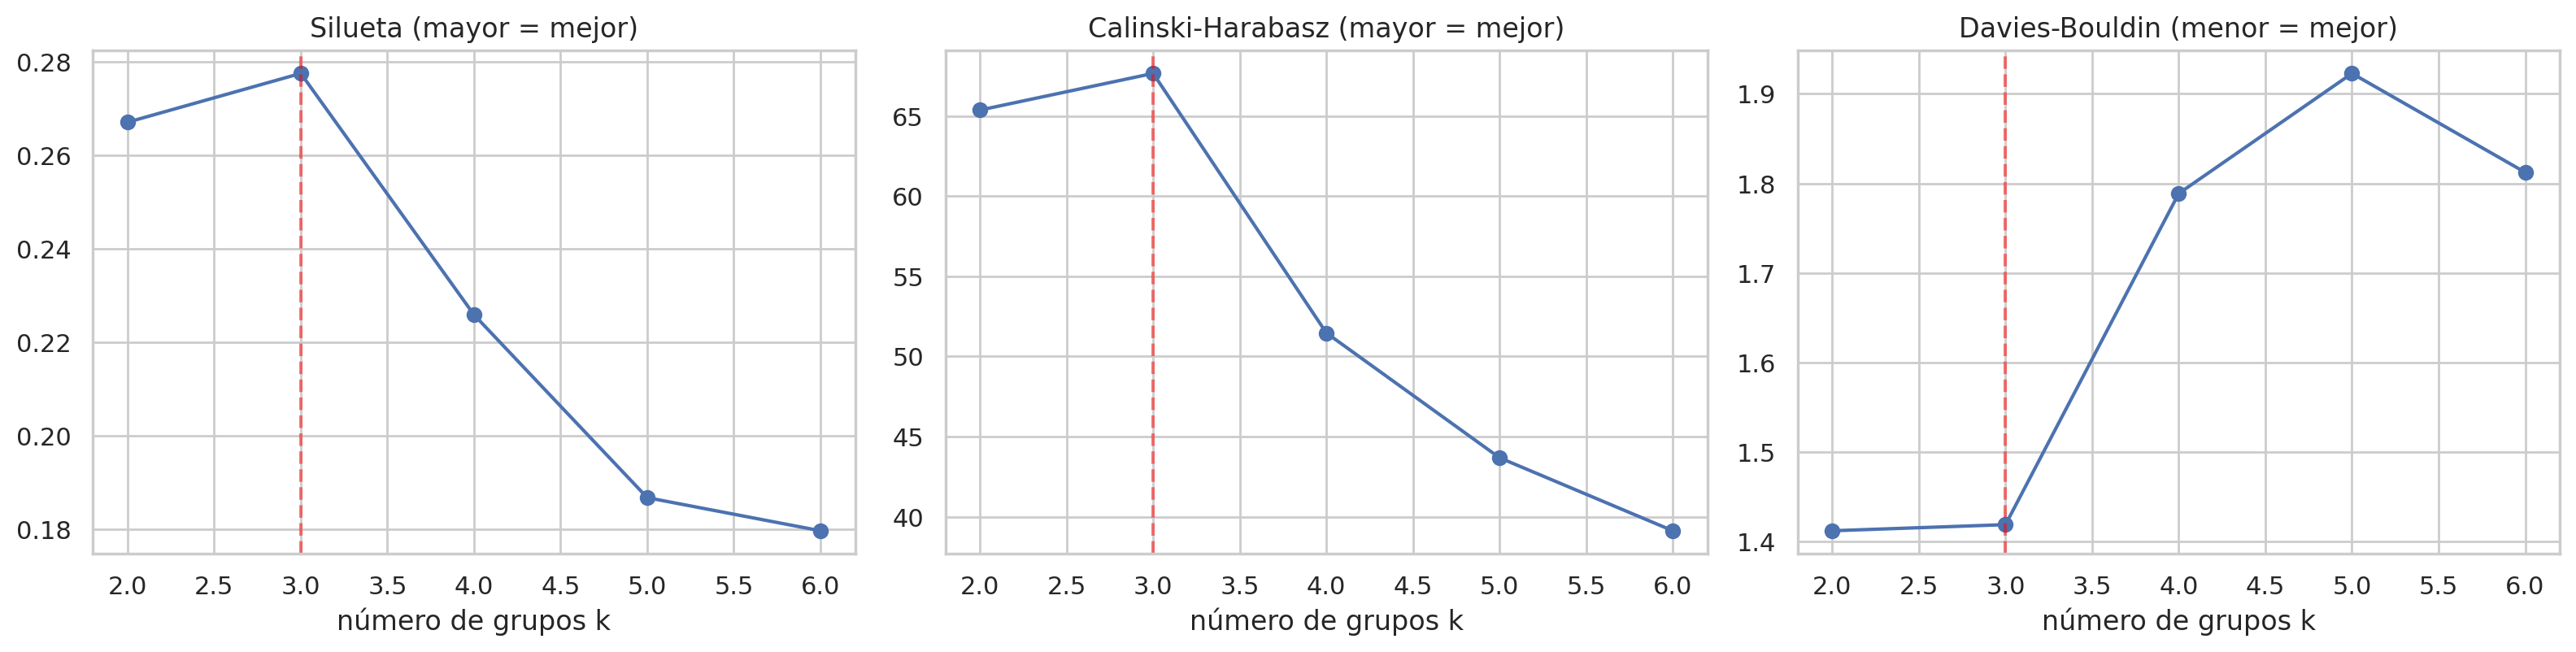

In [58]:
ks = list(range(2, 7))
sil, ch, db = [], [], []
for k in ks:
    lab = AgglomerativeClustering(n_clusters=k, linkage='ward').fit_predict(X_vinos)
    sil.append(silhouette_score(X_vinos, lab))
    ch.append(calinski_harabasz_score(X_vinos, lab))
    db.append(davies_bouldin_score(X_vinos, lab))

fig, ax = plt.subplots(1, 3, figsize=(16, 4.2))
ax[0].plot(ks, sil, 'o-'); ax[0].set_title('Silueta (mayor = mejor)')
ax[1].plot(ks, ch, 'o-');  ax[1].set_title('Calinski-Harabasz (mayor = mejor)')
ax[2].plot(ks, db, 'o-');  ax[2].set_title('Davies-Bouldin (menor = mejor)')
for a in ax: a.set_xlabel('número de grupos k'); a.axvline(3, ls='--', c='red', alpha=.5)
plt.tight_layout(); plt.show()

**Interpretación.** La **silueta** y **Calinski-Harabasz** alcanzan su **máximo en $k=3$** y caen después; **Davies-Bouldin** es mínimo en $k=2$–$3$. Los tres criterios coinciden en **3 grupos**, que además es el número real de tipos de vino. Fijamos $k=3$, dibujamos el **dendrograma** y **validamos** la solución.

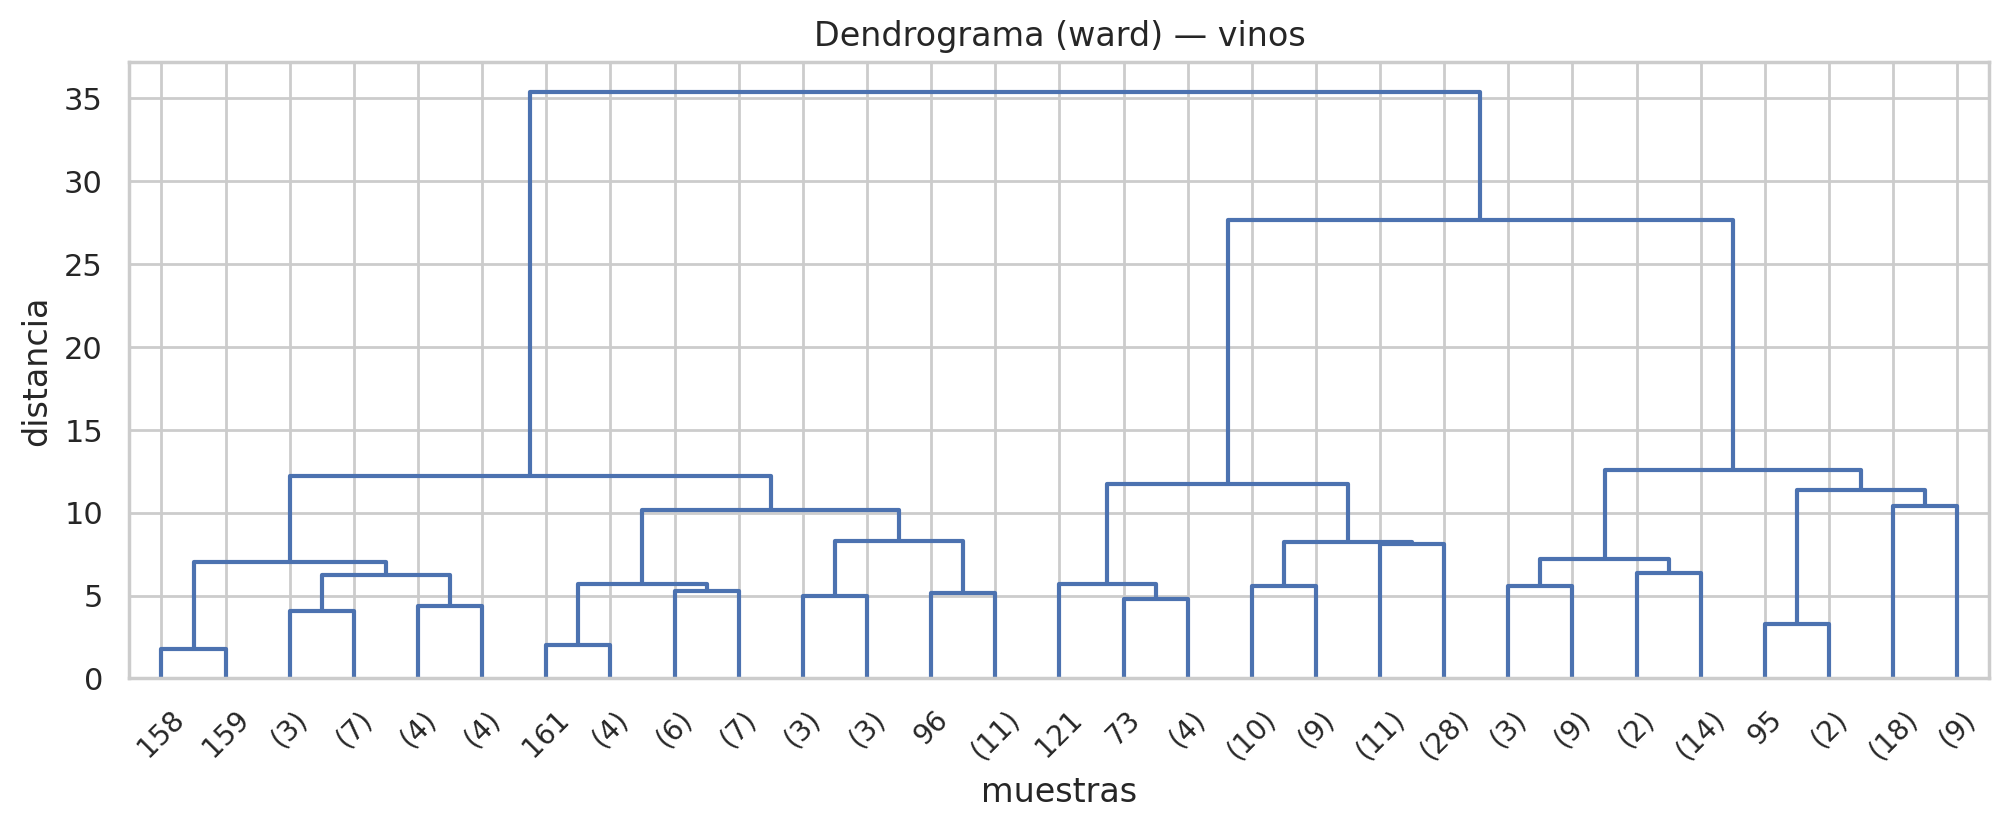

In [59]:
modelo = AgglomerativeClustering(n_clusters=3, linkage='ward', compute_distances=True).fit(X_vinos)

plt.figure(figsize=(12, 4))
plot_dendrogram(modelo, truncate_mode='level', p=4, color_threshold=0)
plt.title('Dendrograma (ward) — vinos'); plt.xlabel('muestras'); plt.ylabel('distancia'); plt.show()

Precisión: 0.927


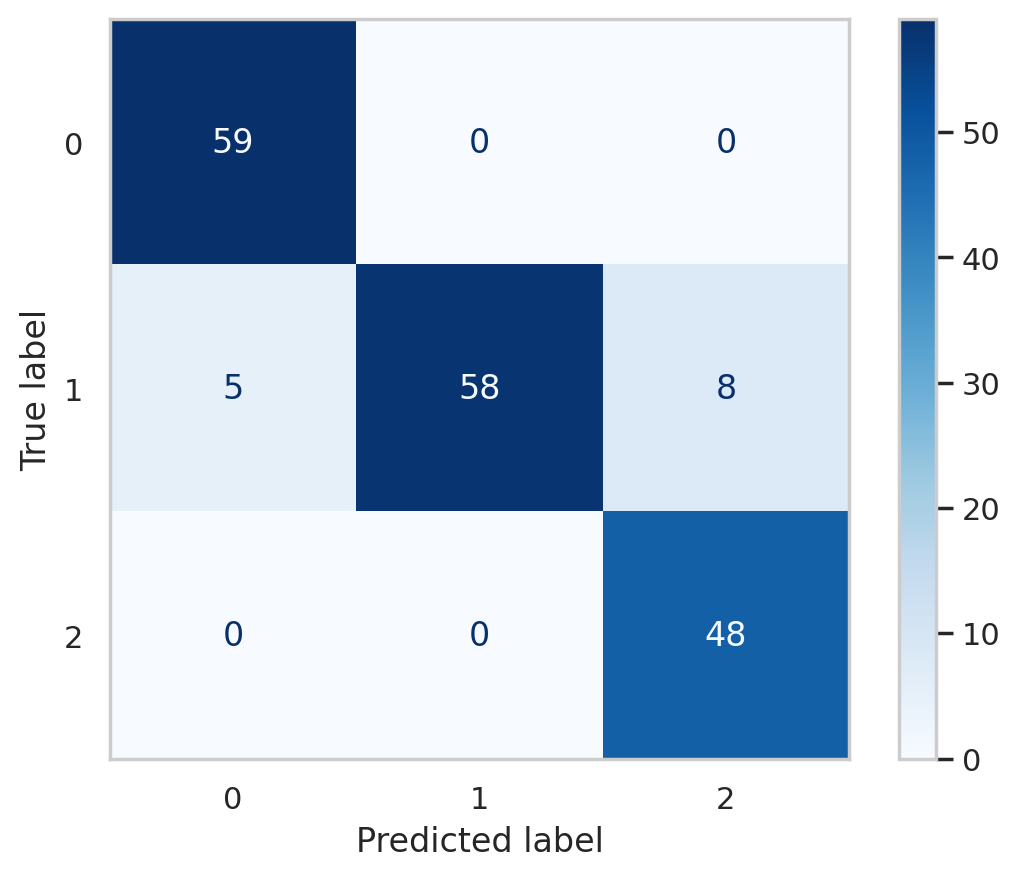

In [60]:
# voto mayoritario para comparar con la etiqueta real
labels = np.zeros_like(modelo.labels_)
for i in range(3):
    mask = modelo.labels_ == i
    labels[mask] = np.bincount(y_vinos[mask]).argmax()
print('Precisión:', round(accuracy_score(y_vinos, labels), 3))
ConfusionMatrixDisplay(confusion_matrix(y_vinos, labels)).plot(cmap='Blues', values_format='g'); plt.grid();plt.show()

**Interpretación.** El jerárquico **ward** recupera los tres tipos de vino con **precisión ≈ 0.93**, algo por debajo de k-medias (~0.97) en este caso: el enlace ward, como k-medias, busca grupos compactos, pero al construir la jerarquía comete algunas fusiones tempranas que no deshace. El dendrograma confirma tres ramas principales bien separadas.

## <font color="steelblue">8.2. Segmentación de usuarios — Google reviews</font>

Valoraciones medias (1–5) de **24 categorías** de atracciones por usuario. El objetivo es **segmentar usuarios** con gustos parecidos (no hay etiqueta; es segmentación pura).

In [61]:
url = "https://raw.githubusercontent.com/ia4legos/MachineLearning/main/data/google_review_ratings.csv"
g = pd.read_csv(url)
g = g.apply(pd.to_numeric, errors='coerce')
g = g.fillna(g.median(numeric_only=True))         # imputación de posibles nulos
X_g = StandardScaler().fit_transform(g.select_dtypes('number'))
print('Usuarios × categorías:', X_g.shape)

Usuarios × categorías: (5456, 25)


**Dendrograma** (truncado con `lastp`, como vimos en 6.2, para que sea legible con miles de muestras) y **scree** de la silueta para elegir el número de segmentos.

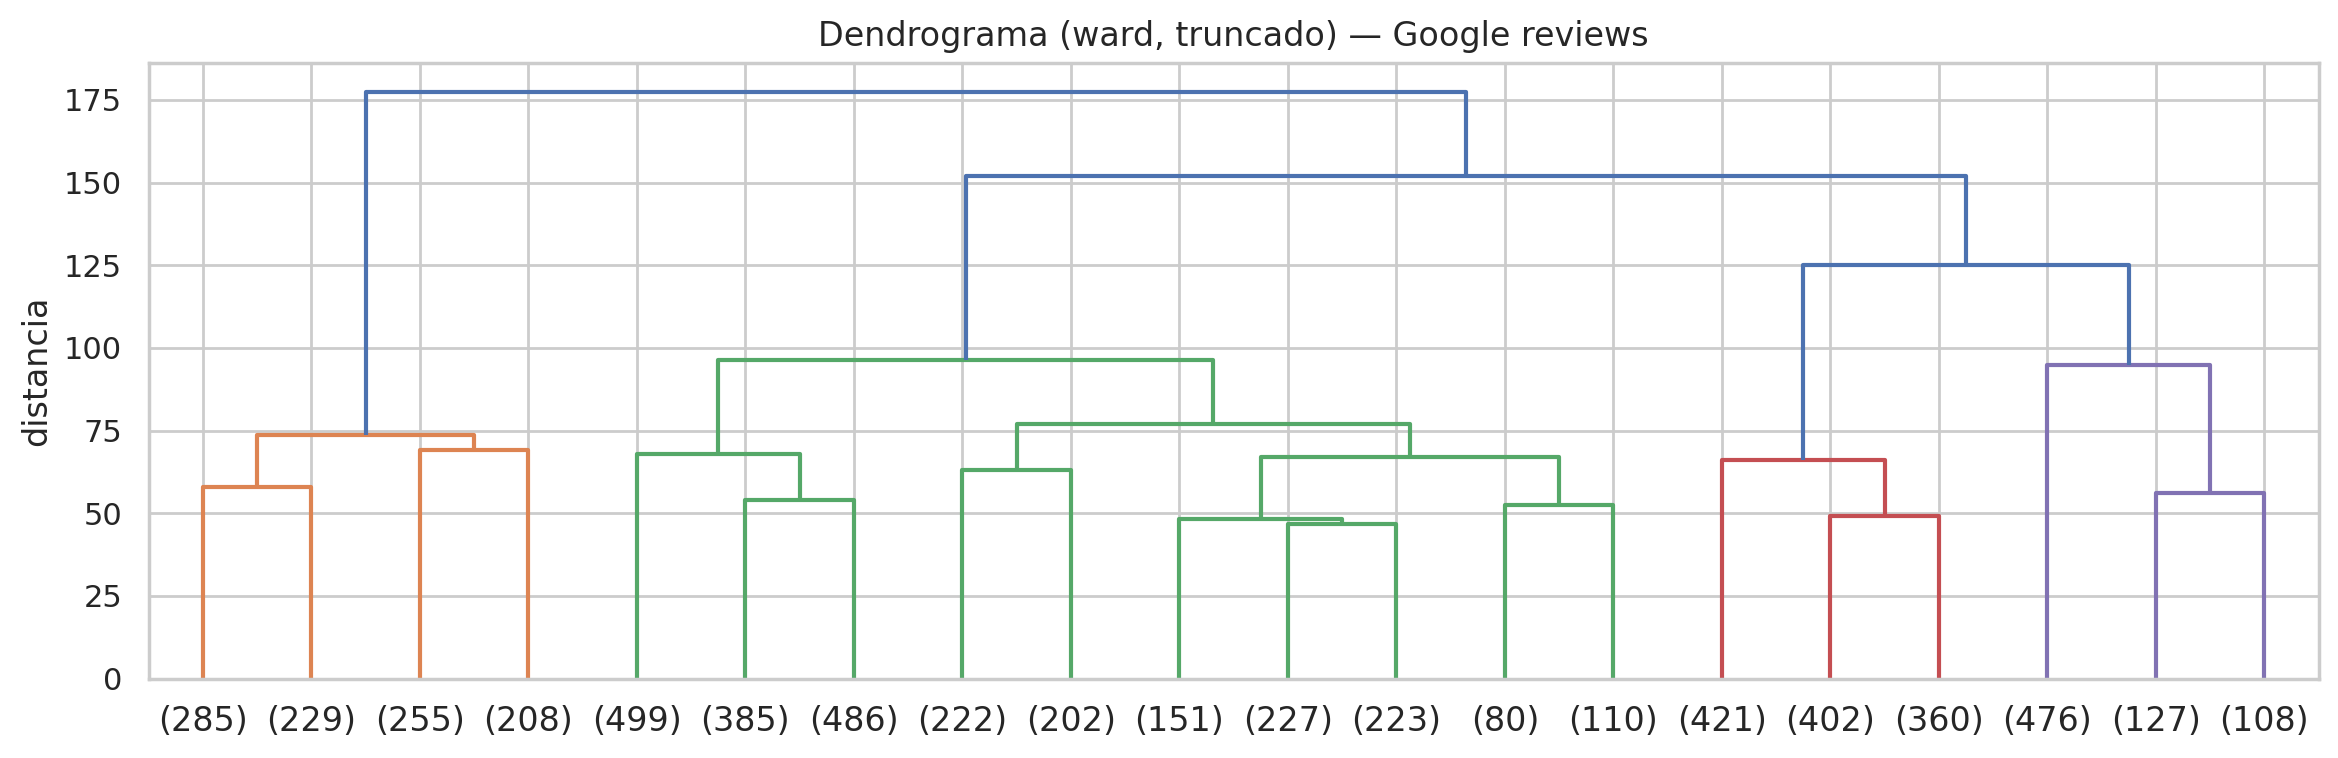

In [62]:
X_g_cleaned = X_g[:, 1:]
Z = linkage(X_g_cleaned, method='ward')
plt.figure(figsize=(14, 4))
dendrogram(Z, truncate_mode='lastp', p=20, show_leaf_counts=True)
plt.title('Dendrograma (ward, truncado) — Google reviews'); plt.ylabel('distancia'); plt.show()

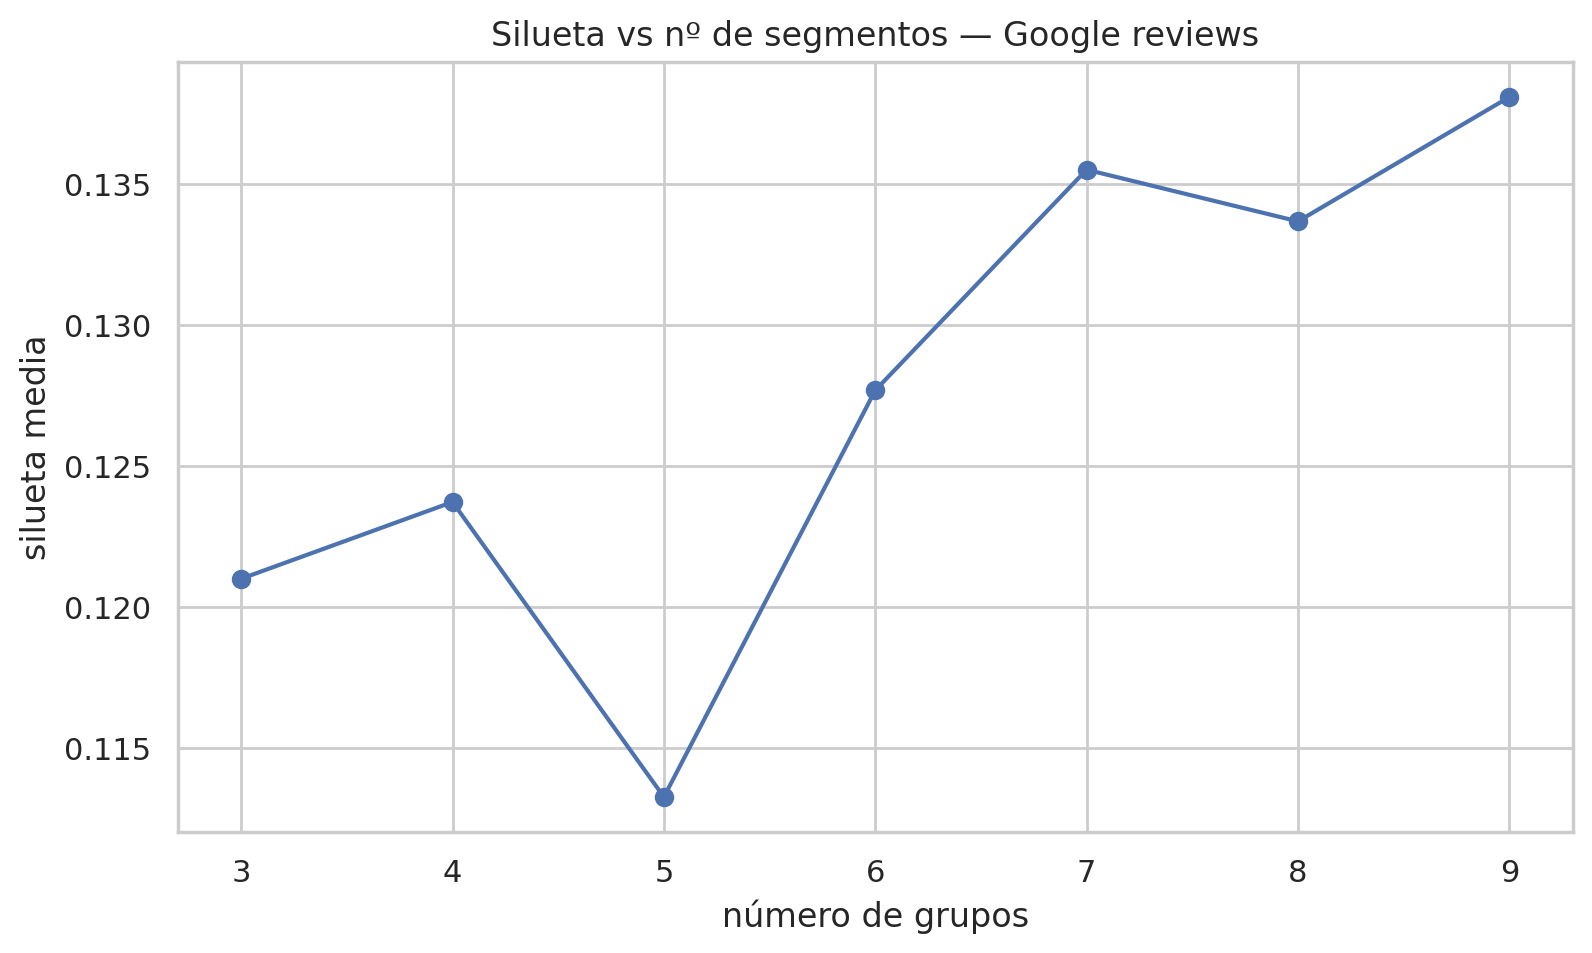

In [63]:
plt.figure(figsize=(9, 5))
plot_scree(X_g_cleaned, 'euclidean', 'ward', 3, 10)
plt.title('Silueta vs nº de segmentos — Google reviews'); plt.show()

**Interpretación.** La silueta es **muy baja** (~0.12) y **casi plana**: apenas mejora al cambiar $k$ (su máximo marginal cae hacia $k\approx 7$–$9$, pero la ganancia es ruido). Esto indica que los usuarios **no forman grupos nítidos** sino un **continuo** de gustos, algo habitual en datos de valoraciones. Como ningún $k$ es claramente mejor, optamos por un número **pequeño e interpretable** de segmentos ($k=4$) y los **caracterizamos** por sus valoraciones medias.

In [64]:
k = 4
g = g.copy()
g['Segmento'] = AgglomerativeClustering(n_clusters=k, linkage='ward').fit_predict(X_g_cleaned)
print('Tamaño de cada segmento:')
print(g['Segmento'].value_counts().sort_index())

# perfil: valoración media por segmento en las 6 primeras categorías
cats = g.select_dtypes('number').columns[:6]
g.groupby('Segmento')[cats].mean().round(2)

Tamaño de cada segmento:
Segmento
0    2585
1     977
2     711
3    1183
Name: count, dtype: int64


,User,Category 1,Category 2,Category 3,Category 4,Category 5
Segmento,,,,,,
0,NaN,1.35,2.61,2.97,3.64,3.95
1,NaN,2.59,2.77,2.53,2.24,2.11
2,NaN,0.87,1.14,1.72,1.77,1.77
3,NaN,1.10,2.03,1.86,2.03,2.20


**Interpretación.** Cada segmento corresponde a un **patrón de gustos** distinto (categorías que valoran alto vs bajo). Aunque la separación es difusa, la jerarquía permite **explorar a distintas resoluciones** (más o menos segmentos) sin reentrenar, y el perfil medio por segmento es directamente accionable para, por ejemplo, recomendación o marketing. Cuando la silueta es tan baja, conviene combinar el clustering con reducción de dimensión (PCA) o revisar las variables.

# <font color="steelblue">9. Conclusiones</font>

Recapitulamos las ideas centrales del cuaderno.

**Qué es el clustering jerárquico.** Construye una **jerarquía de grupos anidados** (un árbol, el **dendrograma**) en lugar de una única partición. Su gran ventaja sobre k-medias es que **no obliga a fijar $k$ de antemano**: una sola ejecución contiene **todas** las particiones, y se elige el número de grupos **cortando el árbol** a la altura deseada (idealmente en un **salto** grande de altura de fusión).

**Las tres decisiones que determinan el resultado.**
- **La distancia entre muestras** (euclídea, Manhattan, coseno, Mahalanobis…): define qué significa «parecido». Con datos direccionales, por ejemplo, el **coseno** acierta donde la euclídea falla.
- **El método de enlace** (distancia entre grupos): **single** sigue formas curvas (lunas, círculos) pero es frágil ante «puentes» de ruido; **complete** y **ward** dan grupos compactos y esféricos; **average** es intermedio. **ward** (solo con métrica euclídea) es la opción por defecto y se parece a k-medias.
- **La altura de corte** (`n_clusters` o `distance_threshold`): fija cuántos grupos salen.

**Herramientas prácticas vistas.**
- **Dendrograma** y su **truncamiento** (`truncate_mode="lastp"/"level"`) para que sea legible con miles de muestras.
- **Restricciones de conectividad** (`connectivity`): hacen que las fusiones respeten la **vecindad/topología** (bandas continuas en el *swiss roll*) y aceleran el cálculo; cuidado, pocos vecinos pueden **desconectar** el grafo.
- **`FeatureAgglomeration`**: la misma idea aplicada a **columnas**, una reducción de dimensión **interpretable** (agrupa variables redundantes) alternativa a PCA.
- **Elección de $k$** con criterios internos: **silueta** (máximo), **Calinski-Harabasz** (máximo) y **Davies-Bouldin** (mínimo), combinados con el dendrograma. Con etiquetas, validación externa con el **ARI** (invariante al nombre de los grupos).

**Qué hemos visto en los ejemplos.**
- **Vinos:** los tres criterios coinciden en $k=3$ (los tres tipos reales) y **ward** los recupera con precisión ≈ 0.93 (algo por debajo de k-medias).
- **Google reviews:** silueta muy baja y plana → los usuarios forman un **continuo** de gustos, no grupos nítidos; aun así la jerarquía permite **explorar a varias resoluciones** y caracterizar segmentos accionables.

**Cuándo elegirlo.** Cuando **no se conoce $k$**, cuando interesa la **estructura anidada** (taxonomías, segmentación a varias resoluciones), cuando se quieren **probar varias métricas o enlaces**, o cuando se usa **single** para formas no convexas. Su límite: es **más costoso** que k-medias en datos muy grandes (de ahí el truncamiento, la conectividad o, directamente, `scipy.linkage` sin construir el árbol completo).

En resumen, el clustering jerárquico cambia «una partición» por «un árbol de particiones»: más información y más flexibilidad, a cambio de más coste y de tres decisiones —distancia, enlace y corte— que conviene tomar con criterio.

# <font color="steelblue">10. Referencias</font>

* Ward, J. H. (1963). *Hierarchical grouping to optimize an objective function*. JASA.
* Lance, G. N. & Williams, W. T. (1967). *A general theory of classificatory sorting strategies* (fórmula de Lance-Williams).
* Müllner, D. (2011). *Modern hierarchical, agglomerative clustering algorithms*.
* Rousseeuw (1987) — coeficiente de silueta; Caliński & Harabasz (1974); Davies & Bouldin (1979).
* Géron, A. (2019). *Hands-On Machine Learning with Scikit-Learn, Keras & TensorFlow*. O'Reilly.
* scikit-learn — *Hierarchical clustering*: https://scikit-learn.org/stable/modules/clustering.html#hierarchical-clustering
* scipy — *Hierarchical clustering* (`scipy.cluster.hierarchy`), parámetro `truncate_mode` de `dendrogram`.
